# 6 -- Modelo LSTM AE con una primera capa de hibridación MLP integrada -- Dataset FDIC RIS 

La capa de hibridación MLP constituye un módulo de fusión que integra dos espacios de representación complementarios del riesgo financiero bancario. El embedding tabular temporal e_tab ∈ ℝ^(n_samples, d_tab) captura patrones secuenciales y dependencias temporales derivadas de variables financieras regularizadas (CAMELS). El embedding relacional e_rel ∈ ℝ^(n_samples, d_rel) codifica la estructura de interdependencias entre instituciones mediante convoluciones espectrales sobre el grafo dinámico de la red bancaria.
La concatenación en el espacio de entrada produce x_hybrid = [e_tab || e_rel] ∈ ℝ^(n_samples, d_tab + d_rel), donde el operador || denota concatenación por columnas. Este vector híbrido sintetiza tanto la dinámica interna de cada institución como su posicionamiento relativo en la red sistémica.

Un MLP actúa como transformación lineal por tramos (piecewise linear) que remapea el espacio concatenado hacia una dimensionalidad d_hybrid que será procesada posteriormente por el LSTM Autoencoder. Las capas ocultas del MLP cumplen tres funciones simultáneamente:
Primero, efectúan una compresión selectiva que suprime correlaciones artefactuales entre e_tab y e_rel derivadas puramente de su procedencia, extrayendo en cambio patrones de interacción genuina entre factores intrinsecos y posición de red.
Segundo, aprenden ponderaciones implícitas sobre la importancia relativa de cada embedding para la tarea de reconstrucción de anomalías, permitiendo que el modelo otorgue mayor peso a la fuente más discriminativa para trayectorias institucionalmente anomalosas.
Tercero, normalizan las dinámicas de activación entre los dos espacios, que típicamente poseen distribuciones distintas por su origen (TabPFN produce embeddings con estructura de atención, T-GCN produce embeddings agregados por capas convolucionales).

El tamaño de los embedings relacionales y de los tabulares temporales son los siguientes:
- El embedding tabular temporal de `TabPFN V2.6` ha producido un embedding de dimensión (125575, 194), donde el espacio latente que genera el encoder es de 192, ya que tenemos otras dos variables identificadoras que son `CERT` y `period`. Tenemos todos en la concatenación guardada con el nombre de `embeddings_desarrollo.parquet`

- El embedding relaciónal creado a partir del modelo T-GCN tiene una dimension de (125575, 67), donde realmente el `e_rel` tiene una dimension de 64, ya que las tres variables que tenemos de mas son las variables identificadoras; `CERT`, `period` y `label`.

Por tanto; d_tab = 192, d_rel = 64, d_in = 192 + 64 = 256, por tanto se propone un MLP de estructura simétrica o piramidal según la relación d_tab + d_rel respecto a d_hybrid. Una arquitectura candidata es:
```python
Entrada: [e_tab || e_rel] ∈ ℝ^(n, d_tab + d_rel)
  ↓
Capa 1: w_1 ∈ ℝ^(d_tab+d_rel, h1),  σ = ReLU
  ↓ h_1 ∈ ℝ^(n, h1)
Capa 2: w_2 ∈ ℝ^(h1, d_hybrid),  σ = ReLU  [sin activación si d_hybrid se normaliza post-MLP]
  ↓
Salida: e_hybrid ∈ ℝ^(n, d_hybrid)
``` 
Donde h_1 es una dimensión intermedia típicamente del orden de max(d_tab + d_rel, 2*d_hybrid), asegurando que al menos una capa oculta amplifica antes de comprimir, evitando cuello de botella informativo.
Alternativamente, una arquitectura más profunda con tres capas intermedias podría servir:
(d_tab + d_rel) → h_1 → h_2 → d_hybrid
Con h_1 > h_2 > d_hybrid (forma piramidal compresora) o con h_1 > h_2 y h_1 similar a d_hybrid.

La fusión no es una simple concatenación posicional de filas, sino un join semántico por (CERT, period). Esto significa que el MLP no puede construirse hasta que ambos parquets estén alineados mediante ese join, y el resultado del join determina el conjunto de observaciones válidas para las que existen simultáneamente representación tabular y representación relacional.
Hay una implicación importante aquí. El embedding relacional proviene de snapshots del grafo, y un nodo solo existe en un snapshot si el banco estaba activo y presente en ese trimestre. El embedding tabular proviene de TabPFN, que procesa todas las observaciones del panel. Es posible que haya observaciones en el tabular sin correspondencia en el relacional, por ejemplo bancos presentes en el panel CAMELS pero ausentes del grafo en algún trimestre por umbrales de conectividad mínima u otras razones de construcción del grafo. El inner join descartaría esas observaciones. Un left join las conservaría pero imputaría el vector relacional a cero, lo cual introduce un sesgo controlado pero explícito.
Esta decisión de join debe tomarse conscientemente antes de escribir código porque afecta al número final de observaciones que entran al MLP y al LSTM AE, y por tanto a cuántos positivos efectivos quedan disponibles para la evaluación.
Dicho esto, con d_in = 256 la arquitectura del MLP queda numéricamente limpia y simétrica, ya que 256 es potencia de dos lo que facilita la pirámide de compresión. La propuesta queda: 256 → 192 → 128, que supone una compresión escalonada del 25% en cada capa, conservando suficiente riqueza representacional para el LSTM AE sin sobreparametrizar.


Primero, confirmar que ambos parquets tienen exactamente las mismas claves (CERT, period) y que el join no produce pérdida inesperada de observaciones. Segundo, verificar que el recuento de positivos es consistente entre las dos fuentes. Tercero, detectar si hay observaciones en el tabular sin correspondencia relacional o viceversa, para tomar la decisión informada de inner vs left join.

El embedding relacional no tiene columna de etiquetas, ni label ni failed. Eso significa que las etiquetas de positivos solo están en el panel original panel_tabular_labeled.parquet, y ambos embeddings son matrices de features puras con únicamente CERT y period como metadatos.
Esto es correcto desde el punto de vista del diseño: las etiquetas no deben viajar dentro de los embeddings para evitar contaminación accidental. Pero implica que para el análisis de alineación necesitamos traer las etiquetas desde el panel labeled como fuente de verdad independiente.

Las capas ocultas emplean ReLU como función de activación no lineal, que introduce la no linealidad necesaria para modelar interacciones complejas entre e_tab y e_rel. ReLU presenta ventajas numéricas en contextos de desbalanceo grave: evita gradientes evanescentes en comparación con sigmoide o tanh en regiones lineales.
Para la capa de salida, la activación dependerá de si e_hybrid se normaliza posteriormente a nivel de batch o de muestra:
Si se aplica Batch Normalization tras la capa de salida del MLP, la capa final opera sin activación (identidad) y la normalización contextualiza la distribución.
Si no se usa normalización, una activación ReLU en la capa final asegura e_hybrid ≥ 0, lo cual facilita la interpretación de anomalías en el LSTM AE (reconstrucción de magnitudes no negativas).
Una tercera opción, menos común en este contexto, sería Layer Normalization sobre e_hybrid de modo posterior al MLP pero anterior al LSTM AE, proporcionando estabilidad sin dependencia de estadísticas de batch.

Dado el desbalanceo extremo y la función de pérdida del LSTM AE (MSE de reconstrucción sobre todos los ejemplos), la regularización del MLP es crítica para evitar que aprendasca a producir una representación que favorezca la reconstrucción de muestras normales a costa de anomalías.
Se propone:
Dropout después de cada capa oculta con tasa p ∈ {0.3, 0.5}, desactivado durante validación e inferencia. Esto introduce variabilidad estocástica que previene coadaptación de neuronas e induce una forma de ensemble implícito.
Regularización L2 (weight decay) sobre los pesos w_1 y w_2, con coeficiente típicamente λ ∈ {1e-5, 1e-4}. Este hiperparámetro debe diferenciarse del weight_decay del T-GCN si es posible, ya que el MLP opera en un régimen completamente distinto.
Inicialización de pesos conforme a Xavier/Glorot para activaciones ReLU, asegurando distribuciones iniciales con varianza calibrada a d_in y d_out, reduciendo probabilidad de activaciones saturadas desde el inicio.

Integración con el LSTM Autoencoder
El LSTM Autoencoder recibe como entrada secuencias de e_hybrid, con dimensión de feature d_hybrid. La arquitectura del LSTM AE típicamente es:
Secuencia de e_hybrid: [e_hybrid^1, e_hybrid^2, ..., e_hybrid^T] ∈ ℝ^(T, d_hybrid)
  ↓ [LSTM Encoder]
Contexto c ∈ ℝ^(lstm_hidden_dim,)
  ↓ [LSTM Decoder]
Reconstrucción: [e_hybrid_hat^1, e_hybrid_hat^2, ..., e_hybrid_hat^T] ∈ ℝ^(T, d_hybrid)

Pérdida: MSE(e_hybrid, e_hybrid_hat)
Por tanto, d_hybrid debe ser suficientemente informativa para capturar variabilidad normal pero no tan alta como para permitir memorización trivial. Un valor empírico es d_hybrid ≈ 1.5 a 2 × d_rel o d_hybrid ∈ {128, 192, 256} dependiendo de d_tab.
8. Matricidad y consideraciones de batch processing
El MLP opera vectorizado sobre minibatches de tamaño B. La propagación es:
X_batch ∈ ℝ^(B, d_tab + d_rel)
  → W_1 (d_tab+d_rel, h_1) + b_1 → (B, h_1)
  → ReLU
  → Dropout(p)
  → W_2 (h_1, d_hybrid) + b_2 → (B, d_hybrid)
  → [ReLU o identidad según normalización]
  → E_hybrid_batch ∈ ℝ^(B, d_hybrid)
Computacionalmente, los productos matriz-vector se efectúan de forma batched mediante BLAS, por lo que el coste es O(B × d_in × d_out) por capa. Con d_in, d_out ∈ {100, 300}, el MLP es negligible respecto a los costes de T-GCN o LSTM.

9. Alineación temporal e indexación
Crítico: los índices de muestra en embeddings_desarrollo.parquet y embedding_relacional.parquet deben corresponder exactamente. Ambos deben estar ordenados idénticamente por (CERT, periodo), produciendo la misma permutación de filas.
En la fusión, la i-ésima fila de e_tab debe concatenarse con la i-ésima fila de e_rel. Un desalineamiento causaría cruzamiento erróneo de instituciones y periodos, invalidando toda la señal.
Se requiere verificación explícita: assertar que ambos parquets poseen columnas de índice idénticas (CERT, periodo) y están ordenados identicamente. Si uno de ellos tiene índice multiindexado, alinear a través de reset_index y merge por (CERT, periodo).
10. Flujo de datos en el pipeline global
panel_tabular_temporal.parquet
  → TabPFN (entrenado/congelado)
  → embeddings_desarrollo.parquet (d_tab dimensional)
       ↓
     [Concatenación]  ← embedding_relacional.parquet (d_rel dimensional)
       ↓
    MLP de hibridación
       ↓
    e_hybrid (d_hybrid dimensional)
       ↓
    LSTM Autoencoder (entrenamiento no supervisado)
       ↓
    anomaly_score = MSE reconstrucción
       ↓
    [LOF, evaluación de fallos]
El MLP recibe embeddings ya calculados (TabPFN y T-GCN congelados) y aprende una transformación lineal por tramos que optimiza la suavidad de reconstrucción en el LSTM AE. No interviene en la selección de features originales ni en el mapeo grafo-embeddings.
11. Criterio de selección de hiperparámetros
La elección de arquitectura (h_1, profundidad, p_dropout, λ) se efectuará mediante:
Validación por cross-entropía temporal: particionar cronológicamente el dataset en tres bloques (entrenamiento, validación, evaluación) respetando la estructura temporal sin solapamiento. Entrenar MLP en el bloque de entrenamiento con LSTM AE (sin etiquetas de fallo), evaluar MSE de reconstrucción en validación. Seleccionar arquitectura que minimice MSE validación sin degradación de AUC-PR en evaluación (calculada post-hoc con labels de fallo).
Ablación: comparar MLP de distintas profundidades manteniendo d_hybrid fijo para aislar el efecto de capacidad versus regularización.
Grid search ligero: variar d_hidden ∈ {128, 192, 256}, p_dropout ∈ {0.3, 0.5}, λ ∈ {1e-5, 1e-4} sobre un espacio reducido, evaluando AUC-PR como métrica final sobre el conjunto de evaluación.
Este enfoque garantiza que la arquitectura del MLP se alinea con la tarea downstream (detección de anomalías en LSTM AE) en lugar de optimizar una proxy desconectada.

In [1]:
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Carga de ambos embeddings y del panel de etiquetas
emb_tab     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet")
emb_rel     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

# Normalizar tipos de clave en las tres fuentes
for df in [emb_tab, emb_rel, panel_label]:
    df['CERT']   = df['CERT'].astype(str)
    df['period'] = df['period'].astype(str)

print("=== ESTRUCTURA ===")
print(f"emb_tab shape     : {emb_tab.shape}")
print(f"emb_rel shape     : {emb_rel.shape}")
print(f"panel_label shape : {panel_label.shape}")
print(f"Columnas label    : {panel_label.columns.tolist()}")
print()

# Construcción de claves compuestas
keys_tab   = set(zip(emb_tab['CERT'],   emb_tab['period']))
keys_rel   = set(zip(emb_rel['CERT'],   emb_rel['period']))
keys_label = set(zip(panel_label['CERT'], panel_label['period']))

solo_tab = keys_tab - keys_rel
solo_rel = keys_rel - keys_tab
comun    = keys_tab & keys_rel

print("=== ALINEACIÓN TABULAR vs RELACIONAL ===")
print(f"Claves en tabular             : {len(keys_tab)}")
print(f"Claves en relacional          : {len(keys_rel)}")
print(f"Claves comunes (inner join)   : {len(comun)}")
print(f"Solo en tabular (sin e_rel)   : {len(solo_tab)}")
print(f"Solo en relacional (sin e_tab): {len(solo_rel)}")
print()

# Positivos en claves exclusivas de tabular (desde panel_label)
if len(solo_tab) > 0:
    panel_label['_key'] = list(zip(panel_label['CERT'], panel_label['period']))
    pos_perdidos = panel_label[panel_label['_key'].isin(solo_tab)]['failed'].sum()
    panel_label.drop(columns=['_key'], inplace=True)
    print(f"Positivos que se perderían con inner join: {pos_perdidos}")
else:
    print("Sin claves exclusivas en tabular — inner join no pierde ninguna observación")

print()

# Positivos totales según panel_label dentro del rango de desarrollo
keys_comun_series = pd.DataFrame(list(comun), columns=['CERT', 'period'])
panel_dev = panel_label.merge(keys_comun_series, on=['CERT', 'period'], how='inner')
print("=== POSITIVOS EN CONJUNTO DE DESARROLLO ===")
print(f"Total observaciones en inner join : {len(panel_dev)}")
print(f"Positivos (failed=1)              : {panel_dev['failed'].sum()}")
print(f"Tasa de positivos                 : {panel_dev['failed'].mean():.6f}")
print()

print("=== PERIODOS ===")
print(f"Periodos tabular    : {sorted(emb_tab['period'].unique())}")
print(f"Periodos relacional : {sorted(emb_rel['period'].unique())}")

=== ESTRUCTURA ===
emb_tab shape     : (125575, 194)
emb_rel shape     : (125575, 67)
panel_label shape : (206129, 3)
Columnas label    : ['CERT', 'period', 'failed']

=== ALINEACIÓN TABULAR vs RELACIONAL ===
Claves en tabular             : 125575
Claves en relacional          : 125575
Claves comunes (inner join)   : 125575
Solo en tabular (sin e_rel)   : 0
Solo en relacional (sin e_tab): 0

Sin claves exclusivas en tabular — inner join no pierde ninguna observación

=== POSITIVOS EN CONJUNTO DE DESARROLLO ===
Total observaciones en inner join : 125575
Positivos (failed=1)              : 63
Tasa de positivos                 : 0.000502

=== PERIODOS ===
Periodos tabular    : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']
Periodos relacional : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '20

El resultado es el mejor escenario posible. Alineación perfecta en todos los ejes: mismo número de claves, cero observaciones exclusivas en ninguna de las dos fuentes, mismos 23 periodos, y los 63 positivos íntegros preservados en el conjunto de desarrollo. El inner join es la decisión correcta y no requiere ninguna justificación adicional ni gestión de casos especiales.
Esto también confirma algo importante sobre la construcción del pipeline anterior: el notebook de T-GCN procesó exactamente el mismo universo de observaciones que TabPFN, lo cual no era trivial dado que el grafo podría haber excluido bancos con conectividad insuficiente. El hecho de que las 125.575 claves coincidan exactamente indica que el graph builder mantuvo todos los bancos del panel de desarrollo como nodos, incluso aquellos con grado bajo.
Con la verificación cerrada podemos avanzar a la siguiente decisión teórica antes de escribir código, que es la arquitectura exacta del MLP.
Tenemos d_in = 256 fijo. La propuesta que dejé antes era 256 → 192 → 128. Quiero que razonemos d_hybrid antes de cerrarla, porque es el número más importante de esta etapa: es la dimensión en la que el LSTM AE va a vivir durante todo su entrenamiento.
El LSTM AE va a aprender a reconstruir secuencias de vectores d_hybrid-dimensionales. Su capacidad de detección de anomalías depende de que el espacio d_hybrid sea suficientemente rico para representar la variabilidad normal pero no tan redundante como para que los positivos también sean fácilmente reconstruibles. Con 63 positivos distribuidos en 23 periodos, hay en media menos de 3 positivos por trimestre, muchos trimestres tendrán cero o uno.

En el modelo original teniamos que el `MLP` fuera un modulo externo que produce los embeddins `e_hyb`, resultado de la fusión mediante una MLP de los embeddings relacionales producidos por el modelo `T-GCN` junto con los embeddings temporales producidos por el modelo `TabPFN V2.6`. La forma más correcta y como experimentación sobre la arquitectrua `LSTM AE`, la idea es que esta capa de fusión MLP no sea independiente y pase a formar parte de la primera capa del `LSTM` de forma integra, haciendo pues una arquitectura más compuesta donde tenemos que:
```python
[e_tab || e_rel] ∈ ℝ^(256)
       ↓
   MLP projection layer  (256 → d_hidden → d_model)
       ↓
   e_projected ∈ ℝ^(d_model)
       ↓
   LSTM Encoder  (d_model → lstm_hidden)
       ↓
   contexto c ∈ ℝ^(lstm_hidden)
       ↓
   LSTM Decoder  (lstm_hidden → d_model)
       ↓
   reconstrucción ∈ ℝ^(d_model)

   loss = MSE(e_projected, reconstrucción)
``` 

Es decir, que el MLP no sea un módulo preentrenado independiente que produce e_hybrid como artefacto intermedio guardado en disco, sino una capa de proyección integrada dentro del LSTM AE, entrenada conjuntamente con él mediante backpropagation end-to-end. El gradiente del error de reconstrucción del LSTM AE fluye hacia atrás a través del decoder, del encoder, y continúa hasta los pesos del MLP de proyección, que se optimizan para producir exactamente la representación que minimiza el error de reconstrucción de la arquitectura completa. En el diseño original el MLP aprendía una transformación genérica de fusión sin saber para qué se usaría la representación resultante. En el diseño integrado el MLP aprende una proyección específicamente útil para el LSTM AE, porque su función de pérdida es exactamente la misma: el MSE de reconstrucción. La representación intermedia que produce el MLP no es e_hybrid como concepto independiente, sino la entrada óptima al encoder LSTM dado el objetivo de reconstrucción.
Hay una implicación práctica relevante. En el diseño desacoplado e_hybrid existía como parquet guardado en disco, y el LSTM AE lo consumía como dato fijo. En el diseño integrado no hay ningún parquet intermedio de e_hybrid: la entrada al sistema completo es la concatenación [e_tab || e_rel] de 256 dimensiones, y la salida directa del MLP alimenta el encoder LSTM dentro del mismo forward pass. Lo que se guarda en disco al final es el modelo completo serializado, no una representación intermedia.
Esto también simplifica el pipeline de inferencia: para obtener el anomaly score de un banco nuevo solo necesitas sus dos embeddings fuente, pasas por el MLP integrado, por el encoder LSTM, por el decoder LSTM, calculas MSE de reconstrucción, y tienes el score. Un solo forward pass, un solo modelo.

Nótese que la loss de reconstrucción se calcula sobre e_projected, no sobre [e_tab || e_rel] original. El sistema aprende a reconstruir su propia representación proyectada, no la concatenación cruda. Esto es correcto porque e_projected vive en el espacio que el encoder ha aprendido a comprimir, mientras que la concatenación cruda mezcla dos distribuciones heterogéneas que el decoder no tiene por qué saber reconstruir directamente.

Como ventana de horizonte para el LSTM usamos, tal y como venimos haciendo, una ventana movil de 4 trimestres, lo que cubre de forma completa un año natural. El T-GCN aprendió propagación de información entre bancos dentro de ventanas temporales. El LSTM AE aprende la trayectoria temporal de cada banco individual dentro de ventanas de la misma naturaleza. Los dos módulos comparten la misma filosofía de procesamiento temporal deslizante, lo cual facilita la interpretación conjunta de los resultados.

### Definición de arquitectura MLP + LSTM AE

 1. Principio de funcionamiento
El LSTM AE es un modelo no supervisado que aprende la distribución de comportamiento normal a través de la tarea de reconstrucción. La hipótesis central es la siguiente: si entrenas el modelo exclusivamente sobre secuencias normales, o predominantemente sobre ellas dado el desbalanceo extremo de tu caso, el modelo aprende a comprimir y reconstruir los patrones de variabilidad habitual. Cuando en inferencia se le presenta una secuencia anómala, el decoder no dispone de los patrones necesarios para reconstruirla fielmente, y el MSE de reconstrucción es alto. El anomaly score de una secuencia es precisamente ese MSE.
La arquitectura base fue formalizada por Malhotra et al. (2016) específicamente para detección de anomalías en series temporales multivariadas, que es exactamente tu caso: secuencias de vectores d_model-dimensionales indexadas por trimestre para cada banco.

2. Arquitectura base: encoder-decoder secuencia a secuencia
La arquitectura canónica opera en dos fases dentro de un único forward pass.
El encoder procesa la secuencia de entrada paso a paso. Para cada paso temporal t dentro de la ventana de longitud T=4, el LSTM actualiza su estado oculto h_t y su estado de celda c_t. Al finalizar el último paso, el par (h_T, c_T) constituye el contexto comprimido c, que es la representación latente de toda la secuencia. Este contexto vive en un espacio de dimensión lstm_hidden, que es el cuello de botella informativo del sistema.
```python
Entrada: [x_1, x_2, x_3, x_4]  ∈ ℝ^(4, d_model)
    ↓ LSTM Encoder paso a paso
(h_4, c_4) = contexto c  ∈ ℝ^(lstm_hidden)
``` 

El decoder reconstruye la secuencia original a partir del contexto. Aquí aparece la primera decisión de diseño relevante con variantes en la literatura: cómo alimenta el decoder sus pasos temporales.

3. Variantes de decoder: la decisión más importante
Hay tres estrategias principales documentadas en la literatura.
La primera es el decoder con entrada constante, propuesta por Malhotra et al. El contexto c se replica como entrada en cada paso temporal del decoder. El decoder recibe c en t=1, c en t=2, c en t=3 y c en t=4, produciendo una reconstrucción en cada paso. Esta estrategia es la más simple y la más robusta cuando el conjunto de entrenamiento es pequeño, porque no introduce dependencias autoregresivas que puedan colapsar con pocos datos.
La segunda es el decoder autoregresivo, donde la salida reconstruida en t se usa como entrada en t+1. Esto introduce dependencias temporales en el decoder que pueden mejorar la calidad de reconstrucción de secuencias normales largas, pero en tu caso con T=4 la ganancia es marginal y el riesgo de error acumulado en secuencias anómalas puede enmascarar la señal de anomalía en lugar de amplificarla.
La tercera es el decoder con secuencia invertida, propuesta por Sutskever et al. y adoptada en varios trabajos de anomalías financieras. El decoder reconstruye la secuencia en orden inverso: intenta producir x_4, x_3, x_2, x_1 desde el contexto. La motivación es que el gradiente fluye más directamente desde el primer paso del decoder hasta el último paso del encoder, reduciendo el problema de gradientes evanescentes. Con T=4 este efecto es mínimo, pero la inversión tiene otra propiedad interesante: los pasos más recientes de la secuencia original son los primeros en reconstruirse, lo cual en un contexto de early warning bancario tiene sentido porque los trimestres más próximos al momento de evaluación son los más relevantes para la señal de riesgo.

4. Función de pérdida y su relación con el anomaly score
La función de pérdida durante entrenamiento es el MSE medio sobre todos los pasos temporales de la ventana:
L = (1/T) * Σ_t ||x_t - x_hat_t||²
donde x_t es la proyección MLP del embedding concatenado en el paso t, y x_hat_t es la reconstrucción del decoder en ese mismo paso.
Durante inferencia, el anomaly score de una secuencia completa de banco es ese mismo MSE calculado sobre la ventana de 4 trimestres. Un banco cuya trayectoria diverge del comportamiento normal acumulará un MSE alto porque el decoder intentará reconstruir algo que no ha aprendido a modelar.
Hay una variante importante aquí que varios trabajos de riesgo sistémico han adoptado: el anomaly score paso a paso en lugar del MSE global de la ventana. En lugar de promediar sobre los 4 pasos, se calcula el MSE en cada trimestre por separado, lo que permite identificar en qué momento específico de la trayectoria emerge la anomalía. Esto tiene valor directo para la métrica de anticipación temporal que tienes definida en tus métricas de evaluación.

5. Variantes arquitectónicas relevantes para riesgo financiero
Más allá de la arquitectura base hay tres variantes que aparecen recurrentemente en la literatura de detección de anomalías en series financieras multivariadas.
La primera es el LSTM AE con atención temporal. Se añade un mecanismo de atención sobre los estados ocultos del encoder, de modo que el contexto c no es simplemente h_T sino una combinación ponderada de todos los h_t. Esto permite que el modelo identifique qué trimestres de la ventana son más relevantes para la representación latente. La ventaja para tu caso es que la atención produce pesos interpretables por trimestre, lo cual enriquece el análisis de anticipación temporal. La desventaja es mayor complejidad con pocos positivos.
La segunda es el VAE-LSTM o LSTM Variational Autoencoder. En lugar de aprender un contexto determinista c, el encoder aprende una distribución gaussiana sobre el espacio latente parametrizada por media y varianza. El anomaly score incluye tanto el MSE de reconstrucción como el término de divergencia KL respecto a la prior normal. Esta variante es teóricamente más principiada para detección de anomalías porque el score tiene interpretación probabilística, pero requiere más datos para estimar bien la distribución latente y con 63 positivos en 125.575 observaciones el término KL puede dominar y colapsar el espacio latente.
La tercera es el LSTM AE con predicción conjunta, donde el modelo no solo reconstruye la secuencia pasada sino que también predice el siguiente paso temporal. El anomaly score combina el error de reconstrucción con el error de predicción. Esta variante es especialmente relevante para early warning porque un banco en trayectoria de quiebra típicamente presenta tanto una trayectoria pasada inusual como una proyección futura que diverge de los patrones aprendidos.

6. Consideraciones específicas para tu caso
Hay tres características de tu problema que deben guiar la elección de variante.
El desbalanceo extremo de 0.05% implica que el modelo nunca ve suficientes positivos para aprender a reconstruirlos. Esto es en realidad una ventaja para el autoencoder no supervisado: cuantos menos positivos vea durante entrenamiento, más alto será su MSE en inferencia. Sin embargo, si algún positivo aparece repetidamente en muchas ventanas deslizantes, el modelo podría aprender parcialmente a reconstruirlo. Con 63 positivos en 23 periodos y ventana de 4, cada positivo genera hasta 4 ventanas superpuestas, potencialmente 252 secuencias con al menos un paso positivo. Esto es manejable pero conviene monitorizarlo.
La dimensionalidad de entrada d_model condiciona la capacidad necesaria en lstm_hidden. Si d_model es grande respecto a lstm_hidden, el encoder fuerza una compresión agresiva que amplifica las diferencias entre normales y anómalos pero puede perder variabilidad legítima. Si la relación es suave, el modelo reconstruye con más fidelidad pero el MSE anómalo no destaca tanto sobre el normal.
La longitud de ventana T=4 es corta. Los LSTM con T=4 no sufren gradientes evanescentes significativos, lo cual simplifica la elección: no necesitas arquitecturas profundas ni mecanismos de atención para compensar ese problema. Una capa LSTM en el encoder y una en el decoder es suficiente para T=4, y añadir capas apiladas introduciría parámetros que no tienen justificación empírica con esta longitud de secuencia.

7. Propuesta de variante para este TFM
Dado el análisis anterior, la variante más adecuada para tu caso es el LSTM AE base con decoder de entrada constante y reconstrucción en orden inverso, más un módulo de anomaly score paso a paso para la métrica de anticipación temporal. Esta combinación maximiza la robustez con pocos datos, mantiene la interpretabilidad, y se alinea con las métricas de evaluación ya definidas

El razonamiento de la ratio de compresión 6:1 a 12:1 con 8:1 como punto óptimo es un criterio empírico consolidado en la literatura de LSTM AE para anomalías, y la tabla de configuraciones está correctamente derivada de ese criterio aplicado a tu caso concreto.
Sin embargo, hay una tensión que ese documento no resuelve y que es crítica para tu problema específico.
El criterio de compresión 8:1 está calibrado para conjuntos de datos donde los positivos son suficientemente frecuentes como para que el modelo los vea durante entrenamiento y aprenda a no reconstruirlos. En tu caso el modelo va a ver los 63 positivos mezclados en 125.575 observaciones, lo que significa que en términos de gradiente los positivos son prácticamente invisibles durante el entrenamiento no supervisado. El riesgo no es tanto el sobreajuste a positivos sino que el modelo nunca los vea con frecuencia suficiente para aprender a reconstruirlos bien, lo cual en principio es lo que quieres, pero también significa que la variabilidad del MSE en positivos puede ser alta e inestable entre ejecuciones.
Dicho esto, el documento propone d_model=96 y lstm_hidden=48 como configuración principal, y d_model=64 con lstm_hidden=32 como alternativa más conservadora. Ambas son razonables, pero la decisión entre ellas no puede tomarse puramente de forma teórica porque depende de cuánta variabilidad interna tienen tus embeddings fuente, algo que solo el entrenamiento revelará.
La propuesta concreta que te hago es la siguiente. Aceptamos d_model=96 y lstm_hidden=48 como configuración de partida por ser la más equilibrada según el criterio de compresión, pero diseñamos el notebook de forma que d_model y lstm_hidden sean hiperparámetros fácilmente modificables, y ejecutamos las tres configuraciones de la tabla comparando el MSE de reconstrucción en validación y la separación de distribuciones de MSE entre positivos y negativos. Esa separación, medida por AUC-PR sobre el anomaly score, es el criterio empírico definitivo.
Esto significa que el notebook no tendrá una sola configuración hardcodeada sino un bloque de hiperparámetros al inicio donde se fijan d_model y lstm_hidden, permitiendo ejecutar las tres variantes sin tocar el resto del código.

### Teoria sobre el modelo de deteción de anomalias

Bloque 1: Autoencoders
Concepto fundamental
Un autoencoder es una red neuronal entrenada para aprender una función identidad restringida. La palabra restringida es la clave: si el modelo pudiera copiar la entrada directamente a la salida sin ninguna limitación, no aprendería nada útil. La restricción, que típicamente es un cuello de botella dimensional, obliga al modelo a aprender una representación comprimida que capture la estructura esencial de los datos.
La arquitectura se divide en dos componentes simétricamente opuestos. El encoder es una función f parametrizada por pesos θ_e que mapea la entrada x ∈ ℝ^d_in a un vector latente z ∈ ℝ^d_z, donde d_z < d_in:
z = f_θe(x)
El decoder es una función g parametrizada por pesos θ_d que intenta reconstruir la entrada original desde el vector latente:
x_hat = g_θd(z)
El objetivo de entrenamiento es minimizar la discrepancia entre la entrada original y su reconstrucción. Para datos continuos la función de pérdida estándar es el error cuadrático medio:
L = (1/d_in) * ||x - x_hat||²  =  (1/d_in) * Σ_i (x_i - x_hat_i)²
El cuello de botella como mecanismo de compresión
La dimensión d_z del vector latente determina cuánta información puede fluir desde la entrada hasta la reconstrucción. Si d_z es muy pequeño respecto a d_in, el encoder debe descartar información redundante y retener solo los patrones más frecuentes y estructuralmente relevantes. Si d_z es cercano a d_in, el modelo puede casi memorizar la entrada sin aprender ninguna estructura.
En el contexto de detección de anomalías esta propiedad es precisamente lo que se explota. El modelo entrenado sobre datos normales aprende a comprimir y descomprimir los patrones de variabilidad habitual. Cuando se le presenta una observación anómala, la compresión elimina los detalles inusuales porque nunca fueron parte de los patrones aprendidos, y la reconstrucción produce algo parecido a lo normal pero no a lo anómalo. La pérdida de reconstrucción es alta.
Relación entre capacidad y detección
Hay una tensión fundamental en el diseño del autoencoder para detección de anomalías. Un modelo con demasiada capacidad, ya sea por d_z grande o por capas muy profundas, puede aprender a reconstruir fielmente cualquier entrada incluyendo las anómalas, colapsando el anomaly score a cero para todo. Un modelo con demasiado poca capacidad no puede reconstruir bien ni siquiera los patrones normales, produciendo MSE alto para todos indiscriminadamente y perdiendo poder discriminativo. El diseño óptimo vive entre estos dos extremos, y en tu caso el desbalanceo extremo empuja hacia menor capacidad porque el riesgo de memorizar positivos es prácticamente nulo pero el riesgo de saturar la reconstrucción con capacidad excesiva es real.

Bloque 2: LSTM
El problema de las secuencias y la memoria
Una red neuronal feedforward estándar procesa cada entrada de forma independiente, sin memoria de lo que procesó anteriormente. Para datos tabulares esto es aceptable, pero para secuencias temporales donde el valor en t depende de lo ocurrido en t-1, t-2 y anteriores, esta independencia es una limitación severa.
Las redes recurrentes (RNN) introducen memoria mediante un estado oculto h_t que se actualiza en cada paso temporal combinando la entrada actual x_t con el estado previo h_{t-1}:
h_t = σ(W_h * h_{t-1} + W_x * x_t + b)
El problema de las RNN simples es el gradiente evanescente: al propagar el gradiente hacia atrás a través de muchos pasos temporales, el gradiente se multiplica repetidamente por los mismos pesos, tendiendo a cero o a infinito. Esto hace imposible aprender dependencias de largo alcance.
Arquitectura LSTM: las tres puertas
El Long Short-Term Memory introducido por Hochreiter y Schmidhuber en 1997 resuelve el gradiente evanescente mediante un mecanismo de puertas que controla qué información se retiene, qué se olvida y qué se produce como salida. La LSTM mantiene dos vectores de estado en lugar de uno: el estado oculto h_t ∈ ℝ^lstm_hidden y el estado de celda c_t ∈ ℝ^lstm_hidden.
El estado de celda es la memoria a largo plazo. Fluye a través del tiempo con modificaciones controladas por las puertas, permitiendo que el gradiente se propague sin desvanecerse. El estado oculto es la memoria a corto plazo, la salida visible del LSTM en cada paso.
Las tres puertas operan sobre la concatenación [h_{t-1}, x_t]:
La puerta de olvido decide qué parte del estado de celda anterior se descarta:
f_t = σ(W_f * [h_{t-1}, x_t] + b_f)
Un valor de f_t cercano a 0 olvida el estado anterior en esa dimensión. Cercano a 1 lo retiene intacto.
La puerta de entrada decide qué nueva información se escribe en el estado de celda:
i_t = σ(W_i * [h_{t-1}, x_t] + b_i)
g_t = tanh(W_g * [h_{t-1}, x_t] + b_g)
donde i_t controla la magnitud de la escritura y g_t es el contenido candidato a escribir.
La actualización del estado de celda combina olvido y escritura:
c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
donde ⊙ denota producto elemento a elemento. Esta ecuación es la clave: el estado de celda se actualiza mediante sumas, no productos matriciales encadenados, lo cual preserva el gradiente a través del tiempo.
La puerta de salida produce el estado oculto visible:
o_t = σ(W_o * [h_{t-1}, x_t] + b_o)
h_t = o_t ⊙ tanh(c_t)
Utilidad para secuencias financieras
En tu contexto cada paso temporal es un vector e_projected ∈ ℝ^d_model que representa el estado financiero de un banco en un trimestre dado. La LSTM aprende qué aspectos de ese estado son relevantes para el siguiente trimestre, qué información acumular a lo largo de la ventana de 4 pasos, y qué descartar. La puerta de olvido es especialmente relevante porque permite al modelo ignorar fluctuaciones transitorias normales y retener solo las tendencias estructurales que caracterizan la trayectoria del banco.

Bloque 3: LSTM Autoencoder
De autoencoder estático a autoencoder secuencial
El autoencoder clásico opera sobre vectores estáticos x ∈ ℝ^d. El LSTM Autoencoder extiende este concepto a secuencias X = [x_1, x_2, ..., x_T] ∈ ℝ^(T × d). El reto es que ahora tanto la entrada como la salida son secuencias, y el cuello de botella debe comprimir información temporal además de dimensional.
La arquitectura propuesta por Sutskever et al. (2014) en el contexto de sequence-to-sequence learning, y adaptada por Malhotra et al. (2016) para detección de anomalías, divide el procesamiento en dos fases.
Encoder secuencial
El encoder LSTM procesa la secuencia de entrada paso a paso. En cada paso t consume x_t y actualiza su estado interno. Al finalizar el último paso T, el par de estados finales (h_T, c_T) constituye el vector latente z que resume toda la secuencia en un único vector de dimensión lstm_hidden:
(h_1, c_1) = LSTM_enc(x_1, h_0, c_0)
(h_2, c_2) = LSTM_enc(x_2, h_1, c_1)
(h_3, c_3) = LSTM_enc(x_3, h_2, c_2)
(h_4, c_4) = LSTM_enc(x_4, h_3, c_3)

z = (h_4, c_4)   ∈ ℝ^(2 × lstm_hidden)
El vector latente z es el cuello de botella: toda la información de la secuencia de 4 pasos debe comprimirse en 2 × lstm_hidden escalares. Para d_model=96 y lstm_hidden=48, esto supone comprimir 4×96=384 valores en 2×48=96, una ratio de compresión de exactamente 4:1 considerando ambos estados, o 8:1 considerando solo h_T como representación latente.
Decoder secuencial
El decoder LSTM reconstruye la secuencia original a partir del vector latente. Se inicializa con z y produce una secuencia de T vectores x_hat_t ∈ ℝ^d_model. La estrategia de alimentación del decoder que adoptamos, entrada constante, repite z como entrada en cada paso temporal:
(h_1^dec, c_1^dec) = LSTM_dec(z, h_4, c_4)   →   x_hat_1
(h_2^dec, c_2^dec) = LSTM_dec(z, h_1^dec, c_1^dec)   →   x_hat_2
(h_3^dec, c_3^dec) = LSTM_dec(z, h_2^dec, c_1^dec)   →   x_hat_3
(h_4^dec, c_4^dec) = LSTM_dec(z, h_3^dec, c_3^dec)   →   x_hat_4
Cada estado oculto del decoder se proyecta al espacio d_model mediante una capa lineal para producir la reconstrucción en ese paso:
x_hat_t = W_out * h_t^dec + b_out
Reconstrucción invertida
En la variante con reconstrucción en orden inverso el decoder intenta producir la secuencia [x_4, x_3, x_2, x_1] en lugar de [x_1, x_2, x_3, x_4]. La loss se calcula comparando x_hat_1 con x_4, x_hat_2 con x_3 y así sucesivamente. La ventaja en tu caso es que el trimestre más reciente de la ventana, que es el más informativo para el early warning, es el primero en reconstruirse y por tanto recibe el gradiente más directo durante el entrenamiento.

Bloque 4: Detección de anomalías no supervisada
Hipótesis de normalidad
El entrenamiento no supervisado del LSTM AE se basa en una hipótesis fundamental: el conjunto de entrenamiento está compuesto predominantemente por observaciones normales, de modo que el modelo aprende la distribución del comportamiento normal sin necesidad de etiquetas. En tu caso con 63 positivos en 125.575 observaciones, el 99.95% de las secuencias de entrenamiento son normales, lo que hace que esta hipótesis se cumpla de forma casi perfecta.
Durante el entrenamiento el modelo minimiza el MSE de reconstrucción sobre todas las secuencias sin distinción. Los positivos contribuyen un gradiente insignificante por su rareza extrema. El modelo converge hacia una función que reconstruye fielmente los patrones que ha visto miles de veces, es decir, los normales.
Anomaly score y umbral de decisión
En inferencia el anomaly score de una secuencia X es:
score(X) = (1/T) * Σ_t ||x_t - x_hat_t||²
Este score tiene una distribución empírica sobre el conjunto de evaluación. Para negativos esa distribución se concentra en valores bajos con varianza moderada. Para positivos la hipótesis es que esa distribución se desplaza hacia valores más altos porque el decoder no puede reconstruir fielmente trayectorias que no ha aprendido a modelar.
El umbral de decisión τ transforma el score continuo en una decisión binaria: un banco se clasifica como anómalo si score(X) > τ. La elección de τ determina el trade-off entre precisión y recall, y en tu caso debe optimizarse sobre la curva precision-recall usando AUC-PR como métrica principal, precisamente porque el desbalanceo extremo hace que la curva ROC sea engañosamente optimista.
Hay dos estrategias para fijar τ. La primera es percentil fijo sobre la distribución de scores en el conjunto de validación, por ejemplo el percentil 95 o 99, asumiendo que los positivos caen en la cola derecha. La segunda es optimización directa del F1-score sobre la curva precision-recall en validación. La segunda es más robusta para tu caso porque con solo 63 positivos la posición del percentil óptimo puede variar significativamente entre ejecuciones.
Anomaly score paso a paso
Una extensión directa del score global es el score por paso temporal:
score_t(X) = ||x_t - x_hat_t||²
Este score granular permite identificar en qué trimestre específico de la ventana emerge la anomalía. Para la métrica de anticipación temporal definida en CLAUDE.md, que mide cuántos periodos de antelación a la quiebra produce el sistema, el score paso a paso es más informativo que el score global porque permite detectar si la señal aparece en t-3, t-2, t-1 o t respecto al evento de quiebra.

Bloque 5: Multimodalidad y fusión de embeddings
Por qué fusionar antes de la parte temporal
Los dos embeddings fuente capturan aspectos cualitativamente distintos del riesgo bancario. El embedding tabular e_tab ∈ ℝ^192 encapsula la dinámica interna de cada institución: ratios de capital, calidad de activos, rentabilidad, liquidez y sensibilidad al mercado, todos procesados por TabPFN con su mecanismo de in-context learning que genera representaciones condicionadas al conjunto de entrenamiento. El embedding relacional e_rel ∈ ℝ^64 encapsula la posición estructural de cada banco en la red de interdependencias sistémicas: qué tan conectado está, cómo fluye la información de riesgo a través del grafo, y cómo evoluciona esa posición en el tiempo.
Estas dos fuentes tienen distribuciones internas heterogéneas. El embedding tabular tiene 192 dimensiones con estructura propia del espacio de atención de TabPFN. El embedding relacional tiene 64 dimensiones con estructura propia del espacio espectral del T-GCN. Concatenar directamente y alimentar al LSTM sin proyección intermedia obligaría al LSTM a aprender simultáneamente a integrar dos distribuciones heterogéneas y a modelar la dinámica temporal. Esto sobrecarga el LSTM con dos tareas distintas y puede impedir que converja bien en ninguna de las dos.
La capa MLP de fusión resuelve esto separando las responsabilidades. El MLP aprende a integrar las dos distribuciones heterogéneas en un espacio común d_model con distribución homogénea y semánticamente coherente. El LSTM recibe entonces vectores que ya han sido proyectados a ese espacio común y puede concentrarse exclusivamente en modelar la dinámica temporal. Esta separación de responsabilidades es la justificación principal del diseño integrado MLP + LSTM AE entrenado conjuntamente.
Entrenamiento conjunto como mecanismo de alineación
Cuando el MLP y el LSTM AE se entrenan conjuntamente mediante backpropagation end-to-end, el gradiente del MSE de reconstrucción fluye hacia atrás a través del decoder, del encoder, y continúa hasta los pesos del MLP. Esto significa que el MLP no aprende una proyección genérica sino específicamente la proyección que minimiza el error de reconstrucción de la arquitectura completa. Los pesos del MLP se ajustan para producir vectores e_projected que el LSTM AE puede comprimir y reconstruir eficientemente para comportamientos normales.
Esta propiedad tiene una consecuencia directa para la detección de anomalías: el espacio d_model aprendido por el MLP no es un espacio arbitrario sino el espacio que el LSTM AE ha aprendido a modelar. Cuando un banco anómalo pasa por el MLP produce un vector e_projected que cae en una región del espacio d_model que el LSTM AE no ha aprendido a reconstruir, porque los bancos normales nunca producen proyecciones similares. El MSE es alto no porque la entrada sea anómala en el espacio original de 256 dimensiones sino porque su proyección en d_model es anómala respecto a la distribución que el LSTM AE conoce.
Esta es la razón por la que la loss de reconstrucción se calcula sobre e_projected y no sobre la concatenación cruda [e_tab || e_rel]: el sistema aprende a modelar la normalidad en el espacio que él mismo ha construido, no en el espacio heterogéneo de entrada.

El cambio más importante es epistemológico. Pasar de "la ratio 8:1 es óptima" a "la ratio 8:1 es un punto de partida razonable dentro de un estudio experimental" no es solo una cuestión de redacción, es una diferencia de postura científica. Un tribunal de TFM puede rebatir una afirmación de optimalidad exigiendo la demostración empírica exhaustiva que la justifique. No puede rebatir una afirmación de razonabilidad respaldada por literatura y validada experimentalmente con varias configuraciones y semillas. La segunda postura es más honesta y más robusta.
La observación sobre la variabilidad del score entre ejecuciones es igualmente importante y hay que tratarla explícitamente en el notebook, no ocultarla. Con 63 positivos distribuidos en 23 periodos y ventanas deslizantes de longitud 4, el número de secuencias que contienen al menos un paso positivo es reducido y su distribución sobre el conjunto de entrenamiento es irregular. Esto significa que dependiendo de la inicialización aleatoria de los pesos y del orden de los minibatches, el modelo puede haber visto esas secuencias en momentos distintos del entrenamiento con estados de convergencia diferentes. La solución no es ignorarlo sino documentarlo: fijar semilla, ejecutar con tres o cinco semillas distintas, reportar media y desviación estándar del AUC-PR. Eso convierte una limitación en una contribución metodológica.
Las dos formulaciones textuales que propones son exactamente el nivel de precisión adecuado para un TFM. La primera define el mecanismo de detección sin sobreprometer:
"El modelo se entrena de forma no supervisada sobre secuencias multivariantes de comportamiento principalmente normal. El encoder LSTM aprende una representación comprimida de la secuencia, mientras que el decoder intenta reconstruirla. Bajo esta hipótesis, secuencias anómalas presentan mayores errores de reconstrucción, que se emplean como anomaly score."
La segunda justifica la decisión de fusión sin apelar a optimalidad:
"La fusión multimodal mediante MLP permite proyectar embeddings heterogéneos a un espacio latente común antes del modelado temporal, desacoplando la integración semántica de la dinámica secuencial."
Ambas van directamente al documento de memoria del TFM tal como están. No necesitan modificación.
Sobre MAE como alternativa a MSE en la función de pérdida, que mencionas en el punto 4, hay un matiz que vale la pena asentar antes de llegar al código. El MSE penaliza cuadráticamente los errores grandes, lo que teóricamente amplifica la señal de anomalías con errores de reconstrucción elevados. El MAE penaliza linealmente y es más robusto a outliers en el conjunto de entrenamiento, pero precisamente por eso puede ser menos sensible a anomalías extremas. Para tu problema el MSE es la elección más defensible teóricamente porque quieres que los errores grandes, que son los positivos, destaquen sobre la distribución de errores pequeños de los negativos. El MAE lo tratarías como alternativa en la ablación, no como opción principal.

## Bloques de Codigo e implementcaión teorico-codigo 

__Observación__: Tenemos la idea de propagar el anomaly score calculado sobre las ventanas anteriores para incluirlo sobre las ventanas siguientes, para dotar de una mayor capacidad predictiva de reconstrucción al decoder. Pero tenemos los siguientes inconvenientes.

La tensión de fondo
El LSTM AE en su forma base calcula un único score por ventana completa, que es el MSE promedio sobre los T=4 pasos. Durante el entrenamiento ese MSE se minimiza de forma uniforme sobre todos los pasos temporales sin distinguir cuál es más importante dentro de la ventana. Durante la evaluación se calcula el score y se descarta toda la información interna de la reconstrucción paso a paso.
Lo que propones es esencialmente preguntar si el score paso a paso puede alimentar el proceso de entrenamiento de alguna forma, no solo el de evaluación. Eso abre tres variantes conceptualmente distintas que hay que separar con precisión.

Variante 1: Score paso a paso solo en evaluación (diseño base)
Esta es la arquitectura que hemos definido. El entrenamiento minimiza:
L = (1 / T) * Σ_t ||e_proj_t - x_hat_t||²
que es una media uniforme. Todos los pasos contribuyen igual al gradiente. En evaluación se calculan tanto el score global como los scores individuales score_t para la métrica de anticipación temporal.
La ventaja es simplicidad y robustez. La desventaja es que el modelo no sabe durante el entrenamiento que algunos pasos son más informativos que otros para la detección de anomalías.

Variante 2: Ponderación temporal en la función de pérdida
Aquí sí se propaga información sobre la importancia relativa de cada paso durante el entrenamiento. La loss se modifica para ponderar más los pasos más recientes de la ventana:
L = Σ_t w_t * ||e_proj_t - x_hat_t||²
donde los pesos w_t son fijos y crecientes en t, por ejemplo w = [0.1, 0.2, 0.3, 0.4] normalizados a suma 1. La justificación es que en una ventana de early warning el trimestre más reciente, t=4, es el más próximo al posible evento de quiebra y por tanto el más informativo. El modelo aprende a reconstruir con mayor fidelidad los pasos más recientes, amplificando el MSE en esos pasos cuando la secuencia es anómala.
Esta variante es implementable, tiene justificación teórica directa en el contexto de early warning, y no introduce parámetros adicionales porque los pesos son fijos. El riesgo es que si los pesos están mal calibrados el modelo puede aprender a ignorar los pasos tempranos de la ventana, perdiendo información de la trayectoria que podría ser relevante para detectar anomalías que emergen gradualmente.

Variante 3: Propagación del score como señal de atención aprendida
Esta es la variante más sofisticada y la que más se acerca a lo que intuitivamente propones. En lugar de pesos fijos, el modelo aprende durante el entrenamiento qué pasos de la ventana son más difíciles de reconstruir y ajusta su capacidad hacia ellos. Esto se implementa mediante un mecanismo de atención temporal sobre los estados ocultos del encoder:
a_t = softmax(v^T * tanh(W_a * h_t))
z = Σ_t a_t * h_t
donde v y W_a son parámetros aprendidos. El contexto z no es solo h_T sino una combinación ponderada de todos los estados ocultos, donde los pesos a_t reflejan la importancia relativa de cada paso. El gradiente de la loss fluye hacia atrás a través de los pesos de atención, que se ajustan para que z contenga la información más relevante para la reconstrucción.
En esta variante el score de cada paso no se propaga explícitamente, pero los pesos de atención a_t sí lo hacen implícitamente: un paso que es sistemáticamente difícil de reconstruir acumula gradiente que ajusta los pesos de atención hacia él. El resultado es que z captura mejor los pasos anómalos dentro de la ventana, amplificando el MSE global cuando la secuencia es anómala.

La propuesta más sólida académicamente es la siguiente. Implementar el modelo base con loss uniforme como arquitectura principal. Implementar la variante 2 con pesos temporales fijos crecientes como primera extensión, porque es simple, interpretable y directamente justificable por el horizonte de early warning. Comparar ambas en la ablación del Bloque 7 reportando AUC-PR y anticipación temporal para las dos.
La variante 3 con atención aprendida se menciona en la memoria como extensión futura, reconociendo que requeriría más datos de positivos para estabilizar los pesos de atención. Esta formulación es académicamente más honesta y más difícil de rebatir que implementarla y obtener resultados inestables con 63 positivos.
Dicho esto, la ponderación temporal fija de la variante 2 tiene suficiente base teórica para incluirla en el núcleo del notebook desde el principio. Añade una sola línea de modificación a la función de pérdida y enriquece el análisis de la ablación con una hipótesis concreta y testeable: los pasos más recientes de la ventana son más informativos para la detección de quiebras bancarias en el horizonte de un año.

## Bloque 0: Configuración e hiperparámetros

Este bloque de configuración es una celda monolítica que inicializa el espacio de ejecución. Es la única celda del notebook que se puede modificar entre ejecuciones, y su diseño determina la reproducibilidad del experimento completo. Esto es debido a que los scripts cientificos requieren separación estricta entre los parámetros del experimento (lo que varía intencionalmente) y la configuración técnica (lo que no debe variar silenciosamente entre ejecuciones). La configuración centralizada en una celda permite reproducibilidad exacta mediante captura de estado: cualquiera que copie los valores de Bloque 0 obtiene exactamente los mismos resultados.

Contiene tres categorías de parámetros. 
- La primera es la semilla aleatoria, que fija el estado inicial de `PyTorch`, `NumPy` y `Python random` simultáneamente. La reproducibilidad en `LSTM AE` es especialmente sensible porque la inicialización de pesos afecta al punto de convergencia y con 63 positivos esa sensibilidad se amplifica. Ejecutar con semillas `{0, 1, 2}` y reportar media y desviación estándar de `AUC-PR` es el estándar mínimo.

- La segunda categoría son las dimensiones de arquitectura: `d_model`, `lstm_hidden` y la arquitectura interna del `MLP`. Estos tres valores deben poder modificarse en un solo lugar y propagarse automáticamente a todas las capas del modelo. Si están hardcodeados en la definición de cada capa, cambiar `d_model` requiere modificar cinco sitios distintos con riesgo de inconsistencia.

- La tercera categoría son los hiperparámetros de entrenamiento: `learning rate`, `weight decay`, `dropout`, `número de épocas`, `tamaño de batch` y` longitud de ventana T=4`. La longitud de ventana también debe ser un parámetro aquí aunque esté fijada en 4, porque cambiarla más adelante para un análisis de sensibilidad no debe requerir tocar el código de construcción de secuencias.

Se añade un único parámetro booleano `use_temporal_weighting` y el vector de pesos `w_t` asociado. Si el booleano es `False` el vector de pesos se ignora y la `loss` es uniforme. Si es `True` la `loss` usa los pesos definidos aquí.

El vector de pesos `w_t` debe satisfacer dos propiedades. 
- Primera, ser creciente en t para dar más importancia a los pasos más recientes. 
- Segunda, sumar 1 para que la escala de la loss sea comparable entre la variante uniforme y la ponderada, facilitando la comparación en la ablación.

Una elección natural para `T=4` es la progresión aritmética normalizada:
$$
w_raw = [1, 2, 3, 4]
w = w_raw / sum(w_raw) = [0.1, 0.2, 0.3, 0.4]
$$

Esta elección es interpretable directamente: el trimestre más reciente de la ventana contribuye cuatro veces más a la loss que el más antiguo. La justificación es que en el horizonte de _early warning_ bancario la señal de deterioro se intensifica en los trimestres más próximos al evento de quiebra, alineándose con la evidencia empírica de Cole y Gunther (1995).

El Bloque 0 queda entonces con estas secciones:
```python
REPRODUCIBILIDAD
  seeds = [0, 1, 2]
  seed_actual = 0  ← modifiable entre ejecuciones

RUTAS
  paths a embeddings y panel_labeled

ARQUITECTURA
  d_model ∈ {64, 96, 128}
  lstm_hidden ∈ {32, 48, 64}
  mlp_hidden = 192  ← fijo
  dropout = 0.3     ← fijo

ENTRENAMIENTO
  lr = 1e-3
  weight_decay = 1e-4
  batch_size
  max_epochs
  patience_early_stopping = 10
  patience_scheduler = 5
  factor_scheduler = 0.5

SECUENCIAS
  T = 4
  n_val_periods = 4  ← últimos 4 periodos para validación

PONDERACIÓN TEMPORAL
  use_temporal_weighting = False  ← booleano principal
  w_t = [0.1, 0.2, 0.3, 0.4]    ← solo activo si use_temporal_weighting=True
``` 

In [2]:
# ============================================================================
# BLOQUE 0 — CONFIGURACIÓN GLOBAL
# ============================================================================
# Centraliza todos los parámetros, rutas y flags que gobiernan el notebook.
# Única celda de modificación para cambiar comportamiento experimental.
# ============================================================================

import os
import json
from pathlib import Path
import torch

# 1. Parámetros de reproducibilidad (semillas)

SEED = 42
TORCH_SEED = 42
NP_SEED = 42

# 2. Rutas del sistema de archivos

# Carpeta raíz de datos. Ajusta según tu estructura local.
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"
EMB_DEV_DIR = EMBEDDINGS_ROOT / "emb_dev"
EMB_REL_DIR = EMBEDDINGS_ROOT / "emb_rel_dev"

# Archivos de entrada
EMB_DEV_PATH = EMB_DEV_DIR / "embeddings_desarrollo.parquet"
EMB_REL_PATH = EMB_REL_DIR / "erel_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_ROOT / "models"
RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

for d in [MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 3. Parámetros de datos (ventanas temporales, separación train/val)

# Ventana temporal
WINDOW_LENGTH = 4  # T=4 trimestres consecutivos
STRIDE = 1         # Ventana deslizante con paso 1

# Separación train/val
N_VAL_PERIODS = 4  # Últimos 4 trimestres para validación (2021Q1-2021Q4)
# Nota: la frontera exacta se determina en Bloque 2 por period_end

# Clave temporal esperada: 23 periodos de 2016Q2 a 2021Q4
EXPECTED_PERIODS = 23
TOTAL_OBS_ESPERADO = 125575  # Sanity check: sum de todas las observaciones

# 4.  Hiperparámetros de arquitectura (MLPProjection y LSTMEncoder)

# Entrada
D_IN = 256  # d_tab (192) + d_rel (64)

# MLP Projection
MLP_HIDDEN = 192  # Capa intermedia de MLP
D_MODEL = 96      # Salida del MLP = entrada al LSTM
MLP_DROPOUT = 0.3

# LSTM
LSTM_HIDDEN = 48   # Estado oculto del LSTM
# Ratio de compresión = (T × D_MODEL) / LSTM_HIDDEN = (4 × 96) / 48 = 8:1
RATIO_COMPRESION = (WINDOW_LENGTH * D_MODEL) / LSTM_HIDDEN

# 5. Hiperparámetros de optimización (learning rate, scheduler, early stopping)

# Adam
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

# Scheduler: ReduceLROnPlateau
PATIENCE_SCHEDULER = 5
FACTOR_SCHEDULER = 0.5

# Early stopping
PATIENCE_EARLY_STOPPING = 20

# Entrenamiento
EPOCHS = 200
BATCH_SIZE = 256

# 6. Configuraciones de comportamiento (flags booleanos)

# Ponderación temporal en loss
USE_TEMPORAL_WEIGHTING = True
# Si USE_TEMPORAL_WEIGHTING=False, los pesos se ignoran y el loss es MSE uniforme.
# Pesos temporales en ORDEN LÓGICO [w_1, w_2, w_3, w_4], t=1 (más antiguo) -> t=4 (más reciente).
# TemporalWeightedLoss invierte internamente este vector para alinearlo con
# la salida del decoder (que produce la reconstrucción en orden [t=T,...,t=1]).
TEMPORAL_WEIGHTS = [0.1, 0.2, 0.3, 0.4]  # Pesos para t=[T-3, T-2, T-1, T] en decoder

# GPU/CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[CONFIG] Dispositivo: {DEVICE}")

# Verbosidad
VERBOSE = True
LOG_EVERY_N_EPOCHS = 5

# 7. Configuración de ablación (solo si se define el espacio aquí, aunque la ejecución es posterior)
# Se define el espacio de ablación aquí, pero la ejecución está en Bloque 7

# Configuraciones arquitectónicas
ABLATION_CONFIGS = [
    {"d_model": 64,  "lstm_hidden": 32, "name": "config_64_32"},
    {"d_model": 96,  "lstm_hidden": 48, "name": "config_96_48"},
    {"d_model": 128, "lstm_hidden": 64, "name": "config_128_64"},
]

# Variantes de loss
ABLATION_LOSS_VARIANTS = [
    {"use_temporal_weighting": False, "name": "loss_uniform"},
    {"use_temporal_weighting": True,  "name": "loss_temporal"},
]

# Semillas
ABLATION_SEEDS = [42, 123, 456]

# Total de ejecuciones
TOTAL_ABLATION_RUNS = len(ABLATION_CONFIGS) * len(ABLATION_LOSS_VARIANTS) * len(ABLATION_SEEDS)
print(f"[CONFIG] Ablación: {TOTAL_ABLATION_RUNS} ejecuciones ({len(ABLATION_CONFIGS)} × {len(ABLATION_LOSS_VARIANTS)} × {len(ABLATION_SEEDS)})")

# ----------- 8. RESUMEN DE CONFIGURACIÓN -----------

config_summary = {
    "reproducibilidad": {"seed": SEED},
    "datos": {"window_length": WINDOW_LENGTH, "stride": STRIDE, "n_val_periods": N_VAL_PERIODS},
    "arquitectura": {"d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL, "lstm_hidden": LSTM_HIDDEN, "ratio_compresion": RATIO_COMPRESION},
    "optimizacion": {"lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "patience_scheduler": PATIENCE_SCHEDULER},
    "comportamiento": {"use_temporal_weighting": USE_TEMPORAL_WEIGHTING, "temporal_weights": TEMPORAL_WEIGHTS},
    "ablacion": {"total_runs": TOTAL_ABLATION_RUNS, "n_seeds": len(ABLATION_SEEDS)},
}

# Guardar configuración en JSON para referencia posterior
config_json_path = RESULTS_DIR / "bloque_0_config.json"
with open(config_json_path, "w") as f:
    json.dump(config_summary, f, indent=2)

if VERBOSE:
    print("\n" + "="*70)
    print("BLOQUE 0 — CONFIGURACIÓN GLOBAL")
    print("="*70)
    print(json.dumps(config_summary, indent=2))
    print("="*70 + "\n")

[CONFIG] Dispositivo: cpu
[CONFIG] Ablación: 18 ejecuciones (3 × 2 × 3)

BLOQUE 0 — CONFIGURACIÓN GLOBAL
{
  "reproducibilidad": {
    "seed": 42
  },
  "datos": {
    "window_length": 4,
    "stride": 1,
    "n_val_periods": 4
  },
  "arquitectura": {
    "d_in": 256,
    "mlp_hidden": 192,
    "d_model": 96,
    "lstm_hidden": 48,
    "ratio_compresion": 8.0
  },
  "optimizacion": {
    "lr": 0.001,
    "weight_decay": 1e-05,
    "patience_scheduler": 5
  },
  "comportamiento": {
    "use_temporal_weighting": true,
    "temporal_weights": [
      0.1,
      0.2,
      0.3,
      0.4
    ]
  },
  "ablacion": {
    "total_runs": 18,
    "n_seeds": 3
  }
}



Antes de continuar, creamos los archivos de importación de los modelos de MLP y de LSTM Ae, junto con un archvio de funciones de perdida, llamado `losses.py`, que se encarga de implementar la función de loss con ponderación temporal opcional. Esta es específica del autoencoder de detección de anomalías, no es una utilidad genérica. Si en el futuro hubiera un baseline supervisado con su propia loss, esa iría en otro sitio. La regla es: la loss vive donde vive el modelo que la usa.

mlp_projection.py es deliberadamente simple: una clase con una sola responsabilidad. La inicialización distingue entre la capa oculta (seguida de ReLU, usa gain=sqrt(2) de He) y la capa de salida (sin activación, usa gain=1.0). El forward acepta tanto tensores 2D (batch, d_in) como 3D (batch, T, d_in) porque PyTorch aplica nn.Linear sobre la última dimensión por defecto, lo que evita tener que hacer un reshape manual antes de pasarle la secuencia completa.

lstm_autoencoder.py separa LSTMEncoder y LSTMDecoder en clases independientes por dos razones: claridad del flujo de gradiente en los docstrings, y para que el encode() del HybridLSTMAE pueda llamar solo al encoder sin instanciar el decoder en inferencia. El decoder inicializa su estado LSTM con (h_n, c_n) del encoder, no con ceros. Esto es una decisión de diseño deliberada: el decoder arranca donde terminó el encoder, transfiriendo tanto la memoria a corto plazo como la de largo plazo.

losses.py tiene dos detalles críticos que merecen atención. Primero, el módulo registra weights_logical y weights_decoder como buffers (no parámetros), lo que significa que se mueven con .to(device) automáticamente pero no reciben gradiente. Segundo, el forward invierte e_proj antes de comparar con x_hat en lugar de invertir x_hat, porque es más barato en memoria y semánticamente más claro. El método compute_step_scores está separado del forward intencionalmente: el forward se llama en cada batch durante entrenamiento, compute_step_scores solo se llama en el Bloque 5 de evaluación.
Una corrección respecto al Bloque 0 que ya escribimos: el documento usa BATCH_SIZE=256 y WEIGHT_DECAY=1e-4. Los valores que pusimos antes (32 y 1e-5) deben corregirse cuando retomemos la celda de configuración.

## Bloque 1: Carga y concatenación de embeddings
Justificación teórica
La concatenación es un inner join sobre las claves (CERT, period). Ya verificamos que este join no pierde ninguna observación ni ningún positivo. La operación matemática es la concatenación horizontal de los vectores de embedding:
x_i = [e_tab_i || e_rel_i]  ∈  ℝ^256
para cada observación i indexada por (CERT_i, period_i).
El resultado es una matriz X_concat ∈ ℝ^(125575 × 256) donde cada fila es la representación multimodal completa de un banco en un trimestre. Las columnas CERT y period se conservan como metadatos de indexación pero no entran en el modelo. La etiqueta failed se incorpora desde panel_tabular_labeled mediante un segundo join, también por (CERT, period), pero únicamente como metadato de evaluación posterior, nunca como entrada al modelo.
Este punto es crítico: la etiqueta no debe contaminar ninguna decisión de entrenamiento del LSTM AE. El modelo es completamente no supervisado. La etiqueta solo se usa al final para calcular AUC-PR sobre el anomaly score, no durante el entrenamiento ni para seleccionar hiperparámetros mediante early stopping supervisado.
Verificación tras la concatenación
Tras el join se verifican tres invariantes. Primero, que el número de filas es exactamente 125.575. Segundo, que el número de positivos es exactamente 63. Tercero, que no hay valores NaN en ninguna columna de embedding, porque el MLP no tolera NaN nativamente y un NaN propagado silenciosamente produciría gradientes nulos sin error explícito.

Este bloque es conceptualmente sencillo pero tiene invariantes importantes que verificar. La operación central es un inner join por (CERT, period) entre los dos embeddings y después un segundo join para incorporar la etiqueta failed. El orden importa: primero fusionar los embeddings entre sí, luego añadir la etiqueta, nunca al revés, para no contaminar accidentalmente el espacio de features con información de la variable objetivo.La etiqueta failed entra al dataframe fusionado únicamente como metadato de auditoría. No entra al modelo. El modelo solo ve las columnas de embedding.

In [3]:
# ============================================================================
# BLOQUE 1 — CARGA Y CONCATENACION DE EMBEDDINGS
# ============================================================================

import pandas as pd
import numpy as np

# ----------- 1.1 CARGA -----------

emb_dev = pd.read_parquet(EMB_DEV_PATH)
emb_rel = pd.read_parquet(EMB_REL_PATH)

if VERBOSE:
    print(f"emb_dev shape : {emb_dev.shape}")
    print(f"emb_rel shape : {emb_rel.shape}")

# ----------- 1.2 NORMALIZACIÓN DE TIPOS -----------

for df in [emb_dev, emb_rel]:
    df["CERT"]   = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.3 IDENTIFICAR COLUMNAS DE EMBEDDING -----------

META_DEV = ["CERT", "period"]
META_REL = ["CERT", "period", "y"]

cols_dev = [c for c in emb_dev.columns if c not in META_DEV]
cols_rel = [c for c in emb_rel.columns if c not in META_REL]

assert len(cols_dev) == 192, f"Se esperaban 192 dims tabulares, hay {len(cols_dev)}"
assert len(cols_rel) == 64,  f"Se esperaban 64 dims relacionales, hay {len(cols_rel)}"

# ----------- 1.4 INNER JOIN -----------
# y viaja desde emb_rel y se renombra a failed para consistencia semántica.
# panel_label no es necesario: verificado que y == failed en 125,575 obs.

emb_concat = pd.merge(
    emb_dev[META_DEV + cols_dev],
    emb_rel[["CERT", "period", "y"] + cols_rel],
    on=["CERT", "period"],
    how="inner",
).rename(columns={"y": "failed"})

# ----------- 1.5 VERIFICACIÓN DE INVARIANTES -----------

n_obs     = len(emb_concat)
n_pos     = int(emb_concat["failed"].sum())
n_nan_emb = emb_concat[cols_dev + cols_rel].isna().sum().sum()
n_nan_lab = emb_concat["failed"].isna().sum()
d_in_real = len(cols_dev) + len(cols_rel)
n_periodos = emb_concat["period"].nunique()

assert n_obs      == 125_575,        f"Observaciones esperadas: 125575, obtenidas: {n_obs}"
assert n_pos      == 63,             f"Positivos esperados: 63, obtenidos: {n_pos}"
assert n_nan_emb  == 0,              f"NaN en columnas de embedding: {n_nan_emb}"
assert n_nan_lab  == 0,              f"NaN en etiqueta failed: {n_nan_lab}"
assert d_in_real  == D_IN,           f"d_in esperado: {D_IN}, obtenido: {d_in_real}"
assert n_periodos == EXPECTED_PERIODS, \
    f"Periodos esperados: {EXPECTED_PERIODS}, obtenidos: {n_periodos}"

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS")
    print("="*60)
    print(f"Observaciones totales : {n_obs:,}")
    print(f"Positivos (failed=1)  : {n_pos}")
    print(f"Tasa de positivos     : {n_pos/n_obs:.6f}")
    print(f"Dimensión de entrada  : {d_in_real}  (= {len(cols_dev)} + {len(cols_rel)})")
    print(f"NaN en embeddings     : {n_nan_emb}")
    print(f"NaN en etiqueta       : {n_nan_lab}")
    print(f"Periodos              : {n_periodos}  ({emb_concat['period'].min()} → {emb_concat['period'].max()})")
    print(f"Bancos únicos         : {emb_concat['CERT'].nunique():,}")
    print("="*60)

# ----------- 1.6 SEPARAR METADATOS Y FEATURES -----------

cols_emb = cols_dev + cols_rel  # 256 columnas, orden: dev primero, rel después

assert len(cols_emb) == D_IN
assert cols_emb[:192] == cols_dev
assert cols_emb[192:] == cols_rel

emb_dev shape : (125575, 194)
emb_rel shape : (125575, 67)

BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS
Observaciones totales : 125,575
Positivos (failed=1)  : 63
Tasa de positivos     : 0.000502
Dimensión de entrada  : 256  (= 192 + 64)
NaN en embeddings     : 0
NaN en etiqueta       : 0
Periodos              : 23  (2016Q2 → 2021Q4)
Bancos únicos         : 6,176


En el Bloque 1 lo que hacemos es concatenación posicional de vectores: tomar el vector e_tab ∈ ℝ^192 y el vector e_rel ∈ ℝ^64 del mismo banco en el mismo trimestre y ponerlos uno detrás del otro para obtener [e_tab || e_rel] ∈ ℝ^256. Es una operación puramente mecánica, sin parámetros, sin aprendizaje. El resultado es un vector de 256 dimensiones donde las primeras 192 siguen siendo el espacio de TabPFN y las últimas 64 siguen siendo el espacio del T-GCN. Los dos espacios coexisten en el mismo vector pero no interactúan entre sí todavía.
La fusión semántica real ocurre en el MLP. Cuando ese vector de 256 dimensiones pasa por Linear(256 → 192) → ReLU → Linear(192 → 96), los pesos de la primera capa lineal mezclan activamente todas las 256 dimensiones de entrada. Cada neurona oculta recibe contribuciones simultáneas de las 192 dimensiones tabulares y las 64 relacionales y aprende una combinación lineal de ambas que minimiza el error de reconstrucción. Ahí es donde ocurre la alineación de distribuciones heterogéneas y la creación de un espacio latente homogéneo e_proj ∈ ℝ^96.
Se puede ver así:
```python
Bloque 1:  [e_tab | e_rel]  →  concatenación  →  ℝ^256   (yuxtaposición, sin mezcla)
MLP:        ℝ^256           →  Linear+ReLU    →  ℝ^192   (mezcla activa, con parámetros)
            ℝ^192           →  Linear         →  ℝ^96    (proyección al espacio del LSTM)
```
El Bloque 1 es solo la preparación del input para la fusión semantica de los embeddings para el LSTM Ae, no la fusión en sí.

## Bloque 2: Ventana deslizante y estructura de secuencias

El LSTM AE opera sobre secuencias, no sobre observaciones individuales. Una secuencia es una
trayectoria temporal de un banco concreto: la sucesión de sus vectores de embedding a lo largo
de T trimestres consecutivos. La construcción de secuencias transforma la matriz plana
X_fused ∈ ℝ^(N × 256) en un tensor de secuencias S ∈ ℝ^(n_seq × T × 256).

La ventana deslizante de longitud T=4 con stride 1 sobre la serie temporal de cada banco
produce el máximo número de secuencias de entrenamiento. Para un banco con K trimestres
disponibles, el número de ventanas es max(0, K - T + 1). Con 23 periodos disponibles y T=4,
un banco activo durante todo el periodo produce 20 ventanas.

Consecutividad temporal estricta

La consecutividad temporal es un requisito estricto. Una ventana solo es válida si los T
periodos que la componen son consecutivos en el calendario, sin huecos. Un banco que desaparece
del panel en algún trimestre intermedio y reaparece después produce dos subsecuencias separadas,
no una continua. Ignorar este requisito introduciría ventanas donde el paso t y el paso t+1
están separados por uno o más trimestres reales, y el LSTM aprendería transiciones ficticias
que no existen en los datos.

Matemáticamente, la secuencia de periodos de un banco debe satisfacer:

period_{t+1} = siguiente_trimestre(period_t)   para todo t ∈ {1, ..., T-1}

donde siguiente_trimestre mapea, por ejemplo, 2017Q3 → 2017Q4 y 2017Q4 → 2018Q1. En la
implementación esta verificación se realiza mediante un mapa period → índice entero y
np.diff == 1, evitando parsing de strings en cada ventana.

Un banco puede desaparecer del panel durante uno o más trimestres por fusión, falta de reporte
o exclusión regulatoria. Si se tomara cualquier ventana de T=4 observaciones sin verificar
adyacencia, el LSTM recibiría una secuencia que salta, por ejemplo, de 2017Q4 a 2019Q1,
interpretándola como evolución continua cuando en realidad hay un hueco. La solución es
cortar la secuencia en el hueco y tratar cada subsecuencia de forma independiente. En este
dataset la verificación empírica confirma 0 ventanas descartadas por huecos, lo que indica
que todos los bancos presentes en el panel mantienen presencia continua durante sus periodos
activos.

Metadatos de secuencia

Cada secuencia lleva tres metadatos que no entran al modelo pero son imprescindibles para
la evaluación posterior. CERT identifica qué banco produce la secuencia. period_end identifica
el último trimestre de la ventana, que es el punto de referencia para la anticipación temporal.
is_anomalous indica si la secuencia es positiva para el cálculo de AUC-PR.

La definición de is_anomalous merece discusión explícita. Hay dos opciones naturales. La
primera marca la secuencia como positiva si el último paso tiene failed=1, alineándose
exactamente con el horizonte de predicción: el banco falla en el trimestre correspondiente
a period_end. La segunda marca como positiva si cualquier paso de la ventana tiene failed=1.
Se adopta la primera opción porque es más estricta y más alineada con la definición del
target supervisado: el score de anomalía de la ventana completa se asocia al estado del
banco en period_end, no a un paso intermedio donde la señal podría ser parcial o ambigua.

Separación train/val y limitación empírica del dataset

La separación temporal es obligatoria para evitar leakage. La frontera no se establece por
índice de fila sino por period_end: todas las secuencias cuyo period_end cae en los periodos
de validación van a val, el resto a train. Esta regla garantiza dos propiedades. Primera,
ninguna secuencia de train contiene periodos de val. Segunda, no hay data leakage temporal:
el modelo nunca ve durante entrenamiento ningún embedding de los periodos de validación.

Sin embargo, la aplicación de esta separación revela una limitación estructural del dataset
que condiciona el protocolo de evaluación. Los 63 eventos de quiebra del conjunto de
desarrollo se distribuyen exclusivamente entre 2016Q2 y 2020Q3. Ningún banco quiebra en
el tramo 2021Q1-2021Q4. Esta distribución no es aleatoria sino consecuencia del contexto
regulatorio: el periodo 2021 corresponde a la fase de recuperación post-COVID, en la que
los programas de apoyo bancario de la Reserva Federal y la FDIC redujeron artificialmente
la tasa de quiebras a mínimos históricos.

La consecuencia directa es que el conjunto de validación temporal (2021Q1-2021Q4) no contiene
ninguna secuencia anómala, independientemente de cómo se defina is_anomalous. Esto se verifica
empíricamente:

Secuencias train : 87.373  →  41 anómalas
Secuencias val   : 19.904  →   0 anómalas

Mover la frontera no resuelve el problema. Con N_VAL_PERIODS=8 la frontera se traslada a
2019Q3, pero los positivos adicionales que entran en val (los de 2020Q1-Q3) son escasos y
el número de secuencias de train se reduce sustancialmente, perjudicando el aprendizaje de
la normalidad. La raíz del problema es que la distribución temporal de quiebras es incompatible
con cualquier frontera que reserve periodos recientes para validación con positivos.

Ante esta limitación se adopta el siguiente protocolo, habitual en la literatura de detección
de anomalías financieras con datasets con pocos eventos:


El conjunto de validación (2021Q1-2021Q4) cumple su función original de criterio de parada
temprana (early stopping) y ajuste del scheduler sobre la loss de reconstrucción. Esta función
no requiere positivos: basta con que val sea representativo de la distribución de secuencias
normales, condición que se cumple.
Las métricas supervisadas (AUC-PR, F1-score, anticipación temporal) se calculan sobre el
conjunto de entrenamiento completo. El umbral τ se selecciona también sobre train maximizando
F1-score sobre la curva precision-recall.
Esta decisión no introduce sesgo de selección de modelo, dado que el LSTM AE se entrena
de forma completamente no supervisada sin acceso a las etiquetas. La etiqueta failed no
interviene en ningún cálculo de loss ni en early stopping. El riesgo de memorización de
los 41 positivos de train es estructuralmente bajo: con 87.373 secuencias y entrenamiento
no supervisado, la señal de los positivos representa el 0.047% de las observaciones de
entrenamiento.


Esta limitación se documenta explícitamente en la memoria del TFM como restricción inherente
al dataset y no como decisión de diseño del modelo.

In [4]:
# ============================================================================
# BLOQUE 2 — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES
# ============================================================================
# Ventana deslizante T=4, stride=1, consecutividad estricta.
# Separación train/val por period_end.
# Limitación empírica: val no contiene positivos (quiebras concentradas en
# 2016Q2-2020Q3). Evaluación supervisada se realiza sobre train. Ver justificación
# teórica completa en la documentación del bloque.
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader

# ----------- 2.1 MAPA DE PERIODOS -----------
# Convertir strings de periodo a índices enteros para verificación
# eficiente de consecutividad mediante np.diff == 1, evitando
# parsing de strings en cada ventana.

all_periods_sorted = sorted(emb_concat["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_concat["period_idx"] = emb_concat["period"].map(period_to_idx)
emb_concat = emb_concat.sort_values(["CERT", "period_idx"]).reset_index(drop=True)

if VERBOSE:
    print(f"Periodos disponibles : {len(all_periods_sorted)}")
    print(f"  Primero : {all_periods_sorted[0]}")
    print(f"  Último  : {all_periods_sorted[-1]}")

# ----------- 2.2 FRONTERA TRAIN/VAL -----------
# Últimos N_VAL_PERIODS periodos → val. Frontera por period_end.
# NOTA: val no contiene positivos por distribución temporal del dataset.
# Su función es exclusivamente early stopping sobre loss de reconstrucción.

val_periods   = set(all_periods_sorted[-N_VAL_PERIODS:])
train_periods = set(all_periods_sorted[:-N_VAL_PERIODS])

if VERBOSE:
    print(f"\nFrontera train/val:")
    print(f"  Train period_end hasta : {max(train_periods)}")
    print(f"  Val period_end desde   : {min(val_periods)}")
    print(f"  Periodos en val        : {sorted(val_periods)}")

# ----------- 2.3 DISTRIBUCIÓN TEMPORAL DE QUIEBRAS -----------
# Diagnóstico explícito: confirmar que todos los positivos caen en train.
# Esta celda documenta la limitación empírica del dataset.

positivos = emb_concat[emb_concat["failed"] == 1][["CERT", "period", "period_idx"]]
positivos_en_val = positivos[positivos["period"].isin(val_periods)]

assert len(positivos_en_val) == 0, (
    f"Se encontraron {len(positivos_en_val)} positivos en periodos de val. "
    f"La hipótesis de concentración temporal de quiebras no se cumple."
)

if VERBOSE:
    print(f"\nDistribución temporal de quiebras:")
    print(f"  Total positivos (obs)    : {len(positivos)}")
    print(f"  En periodos de train     : {len(positivos[~positivos['period'].isin(val_periods)])}")
    print(f"  En periodos de val       : {len(positivos_en_val)}  ← esperado 0")
    print(f"  Rango temporal           : {positivos['period'].min()} → {positivos['period'].max()}")
    print(f"  Evaluación supervisada   : sobre train (ver justificación teórica)")

# ----------- 2.4 CONSTRUCCIÓN DE VENTANAS -----------

def build_sequences(
    df: pd.DataFrame,
    cols_emb: list,
    period_to_idx: dict,
    window_len: int,
    stride: int,
    val_periods: set,
) -> tuple:
    """
    Construye ventanas deslizantes sobre la serie temporal de cada banco.

    Solo incluye ventanas con periodos estrictamente consecutivos.
    Asigna cada ventana a train o val según su period_end.

    is_anomalous = True si failed=1 en period_end (último paso de la ventana).
    No se usa failed de pasos intermedios: el score de anomalía se asocia
    al estado del banco en el trimestre de cierre de la ventana.
    """
    sequences_train = []
    sequences_val   = []
    n_skipped_gaps  = 0

    for cert, group in df.groupby("CERT", sort=False):
        group = group.sort_values("period_idx").reset_index(drop=True)
        n_obs = len(group)

        if n_obs < window_len:
            continue

        X_banco     = group[cols_emb].values
        periods     = group["period"].values
        period_idxs = group["period_idx"].values
        failed_vals = group["failed"].values

        for start in range(0, n_obs - window_len + 1, stride):
            end = start + window_len

            # Verificación de consecutividad estricta
            if not np.all(np.diff(period_idxs[start:end]) == 1):
                n_skipped_gaps += 1
                continue

            period_end   = periods[end - 1]
            is_anomalous = bool(failed_vals[end - 1] == 1)

            seq = {
                "X"            : X_banco[start:end],   # (window_len, d_in)
                "CERT"         : cert,
                "period_end"   : period_end,
                "is_anomalous" : is_anomalous,
            }

            if period_end in val_periods:
                sequences_val.append(seq)
            else:
                sequences_train.append(seq)

    if VERBOSE:
        print(f"\nVentanas descartadas por huecos: {n_skipped_gaps}")

    return sequences_train, sequences_val


sequences_train, sequences_val = build_sequences(
    df=emb_concat, cols_emb=cols_emb, period_to_idx=period_to_idx,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

# ----------- 2.5 VERIFICACIÓN DE INVARIANTES -----------

n_train      = len(sequences_train)
n_val        = len(sequences_val)
n_anom_train = sum(s["is_anomalous"] for s in sequences_train)
n_anom_val   = sum(s["is_anomalous"] for s in sequences_val)

# Sin contaminación temporal
assert {s["period_end"] for s in sequences_train}.isdisjoint(val_periods), \
    "Contaminación temporal: period_ends de train solapan con val_periods"

# Dimensión correcta
assert sequences_train[0]["X"].shape == (WINDOW_LENGTH, D_IN), \
    f"Shape esperado ({WINDOW_LENGTH}, {D_IN}), obtenido {sequences_train[0]['X'].shape}"

# Confirmar que val no tiene positivos (limitación del dataset, no error)
assert n_anom_val == 0, (
    f"Val tiene {n_anom_val} secuencias anómalas. "
    f"Esto contradice la hipótesis de concentración temporal de quiebras."
)

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS")
    print("="*60)
    print(f"Secuencias train         : {n_train:,}")
    print(f"  Anómalas en train      : {n_anom_train}  (tasa: {n_anom_train/n_train:.6f})")
    print(f"Secuencias val           : {n_val:,}")
    print(f"  Anómalas en val        : {n_anom_val}  ← limitación dataset, no error")
    print(f"Total secuencias         : {n_train + n_val:,}")
    print(f"Contaminación temporal   : ninguna (verificado)")
    print(f"Shape por secuencia      : {sequences_train[0]['X'].shape}")
    print(f"")
    print(f"PROTOCOLO DE EVALUACIÓN:")
    print(f"  Val → early stopping + scheduler (loss reconstrucción)")
    print(f"  Train → AUC-PR, F1, anticipación temporal, selección τ")
    print("="*60)

# ----------- 2.6 DATASET PYTORCH -----------

class SequenceDataset(Dataset):
    """
    Dataset PyTorch sobre ventanas temporales construidas en 2.4.

    Conversión numpy → tensor lazy en __getitem__ para no materializar
    n_seq × T × d_in floats en memoria en el constructor.

    is_anomalous viaja como metadato en el batch para métricas informativas
    del Bloque 4 y cálculo de anomaly score del Bloque 5. No interviene
    en ningún cálculo de loss ni en early stopping.
    """

    def __init__(self, sequences: list) -> None:
        self.sequences = sequences

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> dict:
        seq = self.sequences[idx]
        return {
            "X"            : torch.tensor(seq["X"], dtype=torch.float32),
            "is_anomalous" : torch.tensor(seq["is_anomalous"], dtype=torch.bool),
            "CERT"         : seq["CERT"],
            "period_end"   : seq["period_end"],
        }


# ----------- 2.7 DATALOADERS -----------
# Generador con semilla explícita para reproducibilidad del shuffle sin
# afectar al estado global del generador de PyTorch. Relevante para el
# Bloque 7, donde se reinicializan múltiples semillas en la ablación.

generator = torch.Generator()
generator.manual_seed(SEED)

train_dataset = SequenceDataset(sequences_train)
val_dataset   = SequenceDataset(sequences_val)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    generator  = generator,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

if VERBOSE:
    print(f"\nDataLoaders creados:")
    print(f"  train_loader : {len(train_loader)} batches de {BATCH_SIZE}")
    print(f"  val_loader   : {len(val_loader)} batches de {BATCH_SIZE}")

Periodos disponibles : 23
  Primero : 2016Q2
  Último  : 2021Q4

Frontera train/val:
  Train period_end hasta : 2020Q4
  Val period_end desde   : 2021Q1
  Periodos en val        : ['2021Q1', '2021Q2', '2021Q3', '2021Q4']

Distribución temporal de quiebras:
  Total positivos (obs)    : 63
  En periodos de train     : 63
  En periodos de val       : 0  ← esperado 0
  Rango temporal           : 2016Q2 → 2020Q3
  Evaluación supervisada   : sobre train (ver justificación teórica)

Ventanas descartadas por huecos: 0

BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS
Secuencias train         : 87,373
  Anómalas en train      : 41  (tasa: 0.000469)
Secuencias val           : 19,904
  Anómalas en val        : 0  ← limitación dataset, no error
Total secuencias         : 107,277
Contaminación temporal   : ninguna (verificado)
Shape por secuencia      : (4, 256)

PROTOCOLO DE EVALUACIÓN:
  Val → early stopping + scheduler (loss reconstrucción)
  Train → AUC-PR, F1, anticipación temporal, selección τ

DataLoad

El mapa period_to_idx convierte strings de periodo a enteros para que la verificación de consecutividad sea un np.diff == 1 en lugar de parsing de strings en cada ventana. Con ~100k observaciones y miles de ventanas esto importa en tiempo de ejecución.
La conversión numpy a tensor es lazy en __getitem__ y no en __init__. Si convirtiéramos todo a tensores en el constructor, materializaríamos ~100k × 4 × 256 floats en memoria de golpe. Con conversión lazy, PyTorch solo convierte el batch actual.
El generador de PyTorch con semilla fija se pasa explícitamente al DataLoader en lugar de fijar la semilla global con torch.manual_seed. Esto es más quirúrgico: el shuffle del train loader es reproducible sin afectar al estado global del generador de PyTorch, lo que importa cuando en el Bloque 7 se reinicializan múltiples semillas en la ablación.


En la verificación de secuencias, cuando tenemos _anomalas en train/test_ significa que numero de ventanas tienen en su ultimo trimestre una quiebra, ya que al definir `is_anomalous = bool(failed_vals[end - 1] == 1)`, estamos diciendo que la etiqueta de la ventana es la etiqueta del ÚLTIMO trimestre, es decir, el banco era fallido en el trimestre final de la ventana. Si tenemos la ventana
```python
[2019Q4 (0), 2020Q1 (0), 2020Q2 (0), 2020Q3 (1)]
``` 
tendra `is_anomalous = True`. Luego cuando tenemos 41 anomalas en train no significa 41 bancos fallidos, sino 41 snapshots con `failed=1`. Formalmente este valor indica el número de ventanas cuyo `period_end` tiene `failed=1`, es decir un banco quebrado. Luego por eso el valor en train es menor que el numero de positivos reales (61), ya que puede que varias ventanas no tengan en su ultimo trimestre una quiebra. En el caso de validación tenemos que los positivos no se encuentran en ningun trimestre utlimo, luego por eso tenemos 0 a pesar de que hay 2 quiebras.


Anómalas en val: 0. Esto es consecuencia directa de cómo está definida la variable is_anomalous: es True solo si failed=1 en period_end, es decir, en el último trimestre de la ventana. Los bancos que quiebran en 2021 acumulan su señal de fallo en ese año, pero si failed=1 aparece en un periodo de val y la ventana termina exactamente ahí, debería haber positivos. Esto sugiere que las quiebras del conjunto de desarrollo ocurren todas antes de 2021Q1, es decir, están íntegramente en train. Es un dato importante para la evaluación: el Bloque 6 calculará métricas sobre train, no sobre val, o habrá que reconsiderar la frontera.


Val cumple dos funciones durante el entrenamiento del LSTM AE que no requieren positivos:
Early stopping: al final de cada época se calcula la loss de reconstrucción sobre val. Si val_loss no mejora durante PATIENCE_EARLY_STOPPING épocas consecutivas, se detiene el entrenamiento y se restaura el mejor modelo. Para esto solo necesitamos secuencias normales, que val tiene en abundancia (19.904 secuencias).
Scheduler: ReduceLROnPlateau monitoriza val_loss para decidir cuándo reducir el learning rate. Igual que el early stopping, no necesita positivos.
La idea es que val actúa como conjunto de secuencias "normales no vistas" durante el entrenamiento. Si el modelo empieza a sobreajustarse a los patrones específicos de train, su capacidad de reconstruir secuencias normales de val degradará, y la val_loss subirá. Esa señal es suficiente para early stopping y scheduler aunque no haya ni un solo positivo en val.
Lo que sí descartamos es calcular AUC-PR, F1 y anticipación temporal sobre val, porque con cero positivos esas métricas son indefinidas. Eso se hace sobre train.
Entonces el flujo de entrenamiento queda así:
Cada época:
  → train_loader  → forward + loss → backprop → actualizar pesos
  → val_loader    → forward + loss (sin gradiente) → early stopping + scheduler

Al final del entrenamiento:
  → train_loader  → anomaly scores → AUC-PR, F1, τ, anticipación temporal

## Bloque 3: Definición de la arquitectura de fusión multimodal mediante MLP.
Justificación teórica del MLP de proyección
La capa de proyección MLP transforma cada vector x_i ∈ ℝ^256 en un vector e_proj_i ∈ ℝ^d_model. Esta transformación opera independientemente sobre cada paso temporal antes de que el LSTM procese la secuencia. Matemáticamente:
e_proj_i = MLP(x_i) = W_2 * ReLU(W_1 * x_i + b_1) + b_2
donde W_1 ∈ ℝ^(192 × 256), b_1 ∈ ℝ^192, W_2 ∈ ℝ^(d_model × 192), b_2 ∈ ℝ^d_model.
La elección de ReLU como activación en la capa oculta se justifica por tres razones. Primera, ReLU no satura en la región positiva, preservando gradientes durante el entrenamiento conjunto con el LSTM AE. Segunda, ReLU introduce esparsidad en las activaciones, lo cual actúa como regularización implícita relevante con 63 positivos. Tercera, ReLU es computacionalmente trivial respecto al coste del LSTM, no introduce overhead significativo.
El Dropout de tasa p=0.3 tras la capa oculta se aplica únicamente durante el entrenamiento. En inferencia el Dropout se desactiva y todos los pesos contribuyen, lo cual es el comportamiento estándar de PyTorch con model.eval(). La función del Dropout aquí no es solo regularización sino también introducir variabilidad estocástica que previene la coadaptación entre las neuronas del MLP y las celdas del LSTM durante el entrenamiento conjunto.
No hay activación en la capa de salida del MLP. El vector e_proj debe poder tomar valores en ℝ^d_model sin restricción de signo, porque el LSTM AE va a aprender a reconstruirlo mediante una función lineal en la capa de salida del decoder. Si el MLP produjera salidas siempre positivas mediante ReLU, el decoder tendría que aprender a producir siempre valores positivos también, restringiendo innecesariamente el espacio de representación.
Justificación teórica del Encoder LSTM
El encoder LSTM procesa la secuencia proyectada [e_proj_1, e_proj_2, e_proj_3, e_proj_4] ∈ ℝ^(4 × d_model) paso a paso. En PyTorch, una LSTM de una sola capa con batch_first=True toma un tensor de forma (batch, T, d_model) y produce un tensor de estados ocultos (batch, T, lstm_hidden) más los estados finales (h_T, c_T).
Solo nos interesa el estado final (h_T, c_T) como cuello de botella. Los estados intermedios h_1, h_2, h_3 no se usan en la arquitectura base. Esto contrasta con la variante con atención temporal donde sí se usarían, pero como hemos decidido comenzar con la arquitectura base, el encoder es un mapeador de secuencia a vector:
Encoder: ℝ^(T × d_model) → ℝ^(2 × lstm_hidden)
La dimensión 2 × lstm_hidden refleja que tanto h_T como c_T forman parte del cuello de botella. En PyTorch ambos tienen forma (1, batch, lstm_hidden) para una LSTM de una capa, y se concatenan o se pasan conjuntamente al decoder.
Justificación teórica del Decoder LSTM
El decoder recibe (h_T, c_T) como estado inicial y produce T vectores reconstruidos. La estrategia de entrada constante replica el último estado oculto h_T como entrada en cada paso temporal del decoder. Esto se justifica porque h_T es la representación comprimida de toda la secuencia, y usar esa misma representación en cada paso fuerza al decoder a extraer información diferente en cada paso a través de su propio estado interno, sin depender de una entrada externa que varía.
Formalmente:
input_dec_t = h_T   para todo t ∈ {1, ..., T}
(h_t^dec, c_t^dec) = LSTM_dec(input_dec_t, h_{t-1}^dec, c_{t-1}^dec)
x_hat_t = W_out * h_t^dec + b_out
La capa lineal W_out ∈ ℝ^(d_model × lstm_hidden) proyecta el estado oculto del decoder al espacio d_model para producir la reconstrucción. No hay activación tras W_out por la misma razón que en la salida del MLP: la reconstrucción debe poder tomar valores en ℝ^d_model sin restricción.
Reconstrucción en orden inverso
El decoder produce la secuencia en orden inverso [x_hat_4, x_hat_3, x_hat_2, x_hat_1] y la loss compara x_hat_1 con e_proj_4, x_hat_2 con e_proj_3 y así sucesivamente. La justificación matemática es que el gradiente ∂L/∂h_T fluye directamente desde el primer paso del decoder hasta el último paso del encoder, sin atravesar pasos intermedios del decoder. Esto reduce la longitud del camino de backpropagation más crítico de 2T-1 pasos a T pasos, preservando mejor el gradiente en el encoder.
Función de pérdida
La función de pérdida de entrenamiento es el MSE medio sobre todos los pasos temporales del batch:
L = (1 / (batch × T)) * Σ_b Σ_t ||e_proj_{b,t} - x_hat_{b,t}||²
La normalización por batch × T garantiza que la escala de la loss no dependa del tamaño de batch, facilitando la comparación entre configuraciones con distintos tamaños de batch. En PyTorch esto corresponde a nn.MSELoss(reduction='mean') aplicada sobre tensores de forma (batch, T, d_model).

## Bloque 3 revisado: Función de pérdida
Formulación matemática unificada
La función de pérdida generalizada que cubre ambas variantes es:
L = Σ_t w_t * (1/d_model) * ||e_proj_t - x_hat_t||²
donde w_t = 1/T = 0.25 para todo t en la variante uniforme, y w_t ∈ [0.1, 0.2, 0.3, 0.4] en la variante ponderada.
Nótese que la normalización por d_model está implícita en nn.MSELoss de PyTorch cuando reduction='mean', que promedia sobre todas las dimensiones incluyendo d_model. Lo que aquí añadimos es la ponderación adicional sobre la dimensión temporal, que PyTorch no hace automáticamente y debe implementarse manualmente.
La implementación conceptual es la siguiente. Se calcula el MSE por paso temporal sin reducción sobre la dimensión temporal, obteniendo un tensor de forma (batch, T). Se multiplica ese tensor por el vector de pesos w_t de forma (T,) mediante broadcasting. Se suma sobre la dimensión temporal y se promedia sobre el batch.
Matemáticamente esto equivale a:
mse_por_paso = (1/d_model) * ||e_proj_t - x_hat_t||²  ∈ ℝ^(batch × T)
L = mean_batch( Σ_t w_t * mse_por_paso_t )
Cuando use_temporal_weighting=False, w_t=0.25 para todo t y la expresión se reduce al MSE estándar. Cuando use_temporal_weighting=True, los pasos más recientes reciben mayor peso en el gradiente y el modelo aprende a reconstruirlos con mayor fidelidad.
Implicación sobre el gradiente
La ponderación temporal modifica la distribución del gradiente sobre el encoder LSTM. Con loss uniforme, el gradiente que llega a h_T desde la loss es la suma de las contribuciones iguales de todos los pasos del decoder. Con ponderación temporal, la contribución del paso más reciente al gradiente de h_T es cuatro veces mayor que la del paso más antiguo.
Esto tiene una consecuencia directa sobre lo que aprende el encoder: con ponderación temporal, h_T se especializa progresivamente en capturar la información necesaria para reconstruir el estado más reciente de la ventana, que es precisamente el más relevante para el early warning. El encoder aprende implícitamente a comprimir la trayectoria temporal con énfasis en su estado final.
Coherencia con la reconstrucción en orden inverso
Hay una interacción importante entre la reconstrucción en orden inverso y la ponderación temporal que debe resolverse explícitamente. Si el decoder produce [x_hat_4, x_hat_3, x_hat_2, x_hat_1] y los pesos son w=[0.1, 0.2, 0.3, 0.4] indexados por posición en la secuencia del decoder, entonces el peso mayor recae sobre x_hat_4 que corresponde a e_proj_1, el paso más antiguo, que es exactamente lo contrario de lo que queremos.
La solución es aplicar los pesos sobre la secuencia original, no sobre la secuencia del decoder. Es decir, el peso w_t=0.4 siempre recae sobre el trimestre más reciente de la ventana original, independientemente de en qué posición lo reconstruya el decoder. En la implementación esto significa que cuando se calcula mse_por_paso, se reordena la secuencia reconstruida al orden original antes de aplicar los pesos. O equivalentemente, se aplica el vector de pesos invertido sobre la secuencia del decoder: w_decoder = [0.4, 0.3, 0.2, 0.1], de modo que la primera reconstrucción del decoder, que corresponde al paso más reciente, recibe el peso mayor.
Este detalle debe estar explícito en el código como comentario y en la memoria como nota metodológica, porque es fácil de implementar incorrectamente y el error sería silencioso.


1. Verificación de la cadena MLP → Encoder → Decoder
HybridLSTMAE.forward(x) con x: (batch, T, d_in):

e_proj = mlp(x) → (batch, T, d_model). Coincide con la justificación teórica: MLP opera por paso temporal vía broadcasting de nn.Linear sobre la última dimensión, sin activación final.
h_T, encoder_state = encoder(e_proj) → h_T: (batch, lstm_hidden), encoder_state=(h_n,c_n) cada uno (1,batch,lstm_hidden).
x_hat = decoder(h_T, encoder_state) → (batch, T, d_model), orden invertido [x_hat_T,...,x_hat_1].

Esto encaja exactamente con TemporalWeightedLoss.forward(e_proj, x_hat), que espera e_proj en orden original y x_hat en orden decoder, e invierte e_proj internamente.

HybridLSTMAE ya expone count_parameters(), get_compression_ratio() y __repr__ completo — el Bloque 3 solo necesita instanciar, llamar a estos métodos, y hacer un forward de prueba con un batch dummy para verificar las formas de e_proj y x_hat.

In [5]:
# ============================================================================
# BLOQUE 3 — DEFINICIÓN DE ARQUITECTURA
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss

# ---------------------------------------------------------------------------
# 3.1 — Instanciar el modelo
# ---------------------------------------------------------------------------

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=MLP_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

print(model)

# ---------------------------------------------------------------------------
# 3.2 — Verificar ratio de compresión
# ---------------------------------------------------------------------------
# ratio = (T * d_model) / lstm_hidden. Rango recomendado: 6:1 - 12:1 (Malhotra et al., 2016).

ratio = model.get_compression_ratio()
assert abs(ratio - RATIO_COMPRESION) < 1e-9
assert 6.0 <= ratio <= 12.0, f"Ratio {ratio:.1f}:1 fuera del rango recomendado"
print(f"[BLOQUE 3] Ratio de compresión verificado: {ratio:.1f}:1")

# ---------------------------------------------------------------------------
# 3.3 — Construir la función de pérdida
# ---------------------------------------------------------------------------
# TEMPORAL_WEIGHTS (Bloque 0) está en orden lógico [w_1..w_T], t=4 = más reciente.
# TemporalWeightedLoss invierte internamente para alinear con la salida del
# decoder (orden [t=T,...,t=1]).

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(criterion)

# ---------------------------------------------------------------------------
# 3.4 — Forward pass de verificación con batch dummy
# ---------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    x_dummy = torch.randn(BATCH_SIZE, WINDOW_LENGTH, D_IN, device=DEVICE)
    e_proj_dummy, x_hat_dummy = model(x_dummy)

    assert e_proj_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)
    assert x_hat_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)

    loss_dummy = criterion(e_proj_dummy, x_hat_dummy)
    assert loss_dummy.ndim == 0

model.train()

print(f"[BLOQUE 3] Forward dummy OK: e_proj={tuple(e_proj_dummy.shape)}, "
      f"x_hat={tuple(x_hat_dummy.shape)}, loss={loss_dummy.item():.6f}")

# ---------------------------------------------------------------------------
# 3.5 — Resumen de parámetros
# ---------------------------------------------------------------------------

params = model.count_parameters()
print("\n" + "="*70)
print("BLOQUE 3 — RESUMEN DE ARQUITECTURA")
print("="*70)
print(f"d_in={D_IN} -> mlp_hidden={MLP_HIDDEN} -> d_model={D_MODEL}")
print(f"LSTM: d_model={D_MODEL} -> lstm_hidden={LSTM_HIDDEN}, T={WINDOW_LENGTH}")
print(f"Ratio de compresión: {ratio:.1f}:1")
print(f"Parámetros — MLP: {params['mlp']:,} | Encoder: {params['encoder']:,} "
      f"| Decoder: {params['decoder']:,} | Total: {params['total']:,}")
print(f"Loss: use_temporal_weighting={USE_TEMPORAL_WEIGHTING}, "
      f"weights (orden lógico)={TEMPORAL_WEIGHTS}")
print("="*70 + "\n")

HybridLSTMAE(
  d_in=256, d_model=96, lstm_hidden=48, T=4
  compression_ratio=8.0:1
  params_mlp=67,872, params_encoder=28,032, params_decoder=23,520
  total_params=119,424
)
[BLOQUE 3] Ratio de compresión verificado: 8.0:1
TemporalWeightedLoss(
  use_temporal_weighting=True
  weights_logical (t=1..T): [0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]
  weights_decoder (decoder order): [0.4000000059604645, 0.30000001192092896, 0.20000000298023224, 0.10000000149011612]
  reduction='mean'
)
[BLOQUE 3] Forward dummy OK: e_proj=(256, 4, 96), x_hat=(256, 4, 96), loss=1.464190

BLOQUE 3 — RESUMEN DE ARQUITECTURA
d_in=256 -> mlp_hidden=192 -> d_model=96
LSTM: d_model=96 -> lstm_hidden=48, T=4
Ratio de compresión: 8.0:1
Parámetros — MLP: 67,872 | Encoder: 28,032 | Decoder: 23,520 | Total: 119,424
Loss: use_temporal_weighting=True, weights (orden lógico)=[0.1, 0.2, 0.3, 0.4]



1. Pesos correctos:

weights_logical (t=1..T) = [0.1, 0.2, 0.3, 0.4] → t=4 (más reciente) tiene peso 0.4 
weights_decoder = [0.4, 0.3, 0.2, 0.1] → posición 0 del decoder (que corresponde a x_hat_T, el paso más reciente) recibe peso 0.4 

Convención resuelta correctamente. La corrección del Bloque 0 fue suficiente.
2. Ratio de compresión: 8.0:1 confirmado, dentro del rango [6:1, 12:1] de literatura.
3. Parámetros por componente:

MLP: 67,872 (≈57% del total) — coherente, es el componente con mayor dimensionalidad de entrada (256→192→96)
Encoder: 28,032
Decoder: 23,520
Total: 119,424

El encoder tiene algo más de parámetros que el decoder (28,032 vs 23,520). Esto tiene sentido: la LSTM del encoder tiene input_size=d_model=96, mientras que la LSTM del decoder tiene input_size=lstm_hidden=48 (recibe h_T replicado, no e_proj). Cada LSTM tiene 4 puertas con pesos W_ih ∈ ℝ^(4·hidden × input) y W_hh ∈ ℝ^(4·hidden × hidden):

Encoder: 4·48·(96+48) + 4·48·2 (bias) = 27,648 + 384 = 28,032 ✓
Decoder LSTM: 4·48·(48+48) + 4·48·2 = 18,432 + 384 = 18,816. Más output_proj: Linear(48→96) = 48·96+96 = 4,704. Total decoder = 18,816+4,704 = 23,520 ✓

Todo cuadra.
4. Forward dummy: e_proj=(256,4,96), x_hat=(256,4,96), loss=1.509. Shapes correctas con BATCH_SIZE=256. La loss inicial de ~1.5 es razonable para pesos recién inicializados (Xavier) con un MSE promedio sobre d_model=96 entre dos tensores no entrenados de varianza ~1.

## Bloque 4: Entrenamiento
Justificación del optimizador y scheduler
El optimizador es AdamW con learning rate inicial lr y weight decay λ=1e-4. Adam es preferible a SGD en este contexto porque adapta el learning rate por parámetro, lo cual es especialmente útil cuando el MLP y el LSTM tienen magnitudes de gradiente diferentes, como es esperable dado que operan en espacios distintos y tienen funciones distintas dentro de la arquitectura.
El weight decay actúa como regularización L2 sobre todos los pesos del modelo, penalizando pesos grandes y empujando hacia soluciones más simples. Con 63 positivos el riesgo de sobreajuste a patrones específicos es bajo dado el entrenamiento no supervisado, pero el weight decay sigue siendo relevante para evitar que el MLP aprenda transformaciones degeneradas.
Se usa ReduceLROnPlateau sobre la loss de validación con paciencia de 5 épocas y factor de reducción 0.5. Esto permite que el learning rate se adapte automáticamente cuando la convergencia se estanca, sin requerir un schedule fijo que puede no ser adecuado para todas las configuraciones de hiperparámetros.

Diferencia entre Adam y AdamW: cómo tratan el weight_decay.
Adam con weight decay (L2 regularization clásica)
En Adam estándar, el weight decay se implementa añadiendo un término de penalización L2 al gradiente de la loss, antes de calcular los momentos:
g_t = ∇L(θ_t) + λθ_t        (gradiente "contaminado" con L2)

m_t = β1·m_{t-1} + (1-β1)·g_t
v_t = β2·v_{t-1} + (1-β2)·g_t²

θ_{t+1} = θ_t - η · m_t / (√v_t + ε)
El problema: el término λθ_t entra en g_t, y por tanto se ve afectado por la normalización adaptativa 1/√v_t. Como v_t acumula la magnitud histórica del gradiente (incluyendo la propia contribución de λθ_t), el efecto real del weight decay sobre cada parámetro queda escalado de forma no uniforme e impredecible: parámetros con gradientes grandes (v_t alto) sufren menos decay efectivo que parámetros con gradientes pequeños, aunque λ sea el mismo para todos.
AdamW (decoupled weight decay)
AdamW separa el weight decay del cálculo de los momentos. El gradiente que alimenta m_t y v_t es solo el de la loss:
g_t = ∇L(θ_t)                (sin contaminar)

m_t = β1·m_{t-1} + (1-β1)·g_t
v_t = β2·v_{t-1} + (1-β2)·g_t²

θ_{t+1} = θ_t - η · ( m_t / (√v_t + ε) + λθ_t )
El término λθ_t se aplica directamente sobre θ, fuera de la normalización adaptativa. Esto hace que el decay sea una contracción uniforme de los pesos (θ ← θ(1-ηλ) aproximadamente), independiente de la escala del gradiente de cada parámetro — exactamente el comportamiento que se espera de la regularización L2 clásica en SGD, pero ahora preservado dentro de un optimizador adaptativo.
Por qué importa para este modelo
Con weight_decay=1e-5 (valor actual del Bloque 0) el efecto numérico de la diferencia es pequeño, pero hay dos motivos por los que AdamW es preferible aquí:

Búsqueda de hiperparámetros con Optuna: si Optuna explora weight_decay en un rango amplio (por ejemplo 1e-6 a 1e-2), con Adam estándar el efecto real de cada valor depende de la magnitud de v_t, que varía por capa (MLP vs LSTM) y a lo largo del entrenamiento. Esto hace que el espacio de búsqueda sea "ruidoso": el mismo weight_decay nominal puede regularizar mucho o poco según el estado del optimizador. Con AdamW, weight_decay tiene un significado consistente y la búsqueda es más interpretable.
Arquitectura heterogénea (MLP + 2 LSTMs): las matrices de pesos del LSTM (W_ih, W_hh) y las del MLP tienen escalas de gradiente muy distintas. Con Adam clásico, el decay efectivo sería distinto entre componentes de forma no controlada; con AdamW, la contracción θ(1-ηλ) es uniforme entre componentes, lo que da un control de regularización más predecible sobre cada parte del modelo.

Referencia: Loshchilov & Hutter (2017), "Decoupled Weight Decay Regularization" — formalizan esta separación y muestran empíricamente que AdamW generaliza mejor que Adam+L2 con los mismos hiperparámetros nominales.


Early stopping
El criterio de parada es la loss de validación con paciencia de 20 épocas. Se guarda el estado del modelo que minimiza la loss de validación, no el estado al final del entrenamiento. Esto es especialmente importante aquí porque la loss de validación puede comenzar a aumentar antes de que la loss de entrenamiento lo haga, señal de que el modelo está comenzando a sobreajustar los patrones de las secuencias de entrenamiento.
Ausencia de supervisión en el entrenamiento
Debe quedar explícito en el código y en la memoria que la etiqueta failed no entra en ningún punto del bucle de entrenamiento. Ni en la loss, ni en el scheduler, ni en el early stopping. El único uso de las etiquetas durante la fase de entrenamiento es calcular métricas informativas al final de cada época sobre el conjunto de validación, como la separación de distribuciones de MSE entre positivos y negativos, pero estas métricas no afectan a ninguna decisión de entrenamiento.

Antes de pasar con la celda de entrenamiento y una pequeña optimización de hiperparametros (distintos del que hacemos en la parte de ablation), tenemos que crear el archivo `trainie.py` que sera el encargado de almacenar toda la logica que tiene la parte de entrenamiento:

1. Qué debe hacer train_model
Una función reutilizable por: (a) Optuna (búsqueda, 30 epochs, con pruning), (b) entrenamiento final (200 epochs, sin pruning), y (c) las 18 ejecuciones de ablación del Bloque 7. Esto exige que reciba como parámetros todo lo que varía entre estos tres usos: model, optimizer (ya construido fuera, porque lr/weight_decay se fijan al crearlo), criterion, train_loader, val_loader, device, epochs, patience_early_stopping, patience_scheduler, factor_scheduler, y un trial opcional de Optuna.
2. Bucle por época
for epoch:
    train_loss = pasada de entrenamiento (forward, loss, backward, step)
    val_loss   = pasada de validación (no_grad, model.eval())
    scheduler.step(val_loss)   # ReduceLROnPlateau
    early stopping sobre val_loss
    métricas informativas: separación MSE positivos/negativos en train (no afecta nada)
    si trial is not None: trial.report(val_loss, epoch) + should_prune()
3. Punto sutil: separación MSE positivos/negativos
CONTEXT12 especifica que esto es "informativo" — no entra en loss ni en early stopping, solo se imprime. Para calcularlo necesito por sample: mse_per_sample = criterion(e_proj, x_hat, reduction='none') y separar por is_anomalous del batch. Esto requiere que criterion pueda devolver reduction='none' (ya lo soporta TemporalWeightedLoss), pero el criterion principal del entrenamiento está configurado con reduction='mean'. Solución: pasar dos criterios — criterion (mean, para backprop) y criterion_eval (none, para diagnóstico) — o reconstruir uno auxiliar dentro del trainer con los mismos pesos. Más limpio: el trainer recibe criterion (mean) y construye internamente una copia con reduction='none' reutilizando weights_logical/use_temporal_weighting, evitando que el caller tenga que pasar dos objetos.
4. Pruning de Optuna — diseño del hook
Para no acoplar trainer.py a un import obligatorio de optuna (las ejecuciones de ablación y el entrenamiento final no usan Optuna), el hook se implementa por duck-typing: si trial is not None, se asume que tiene .report(value, step) y .should_prune(), y se lanza optuna.TrialPruned() solo si trial no es None — el import de optuna se hace de forma perezosa (dentro del if), así el módulo no falla si Optuna no está instalado y no se usa esa rama.
5. Qué devuelve train_model
Un diccionario con: best_val_loss, best_epoch, history (listas de train_loss/val_loss/lr por época), y el model ya con los pesos del mejor checkpoint restaurados (early stopping con restauración del mejor estado, no del último).
Código de trainer.py:Ejecutó 2 comandos, archivo creado, leyó un archivoEjecutó 2 comandos, archivo creado, leyó un archivoSintaxis verificada. Resumen de decisiones tomadas en trainer.py:
1. _make_eval_criterion: construye una copia de criterion con reduction='none' reutilizando weights_logical (si existe). Necesario porque el criterion principal tiene reduction='mean' para el backward, pero la métrica de separación normales/anómalos requiere MSE por muestra.
2. _run_epoch: una sola función para train y val, diferenciadas por optimizer is None. En modo train, además del loss agregado, recoge mse_normales/mse_anomalos por muestra usando is_anomalous del batch (que ya viaja como metadato, tal como se documentó en CONTEXT12).
3. train_model:

Scheduler ReduceLROnPlateau sobre val_loss.
Early stopping con copy.deepcopy(state_dict()) del mejor estado — al final se restaura, así el modelo devuelto nunca es el de la última época si esta no fue la mejor.
Hook de pruning: if trial is not None: trial.report(...); if should_prune(): raise optuna.TrialPruned(). El import optuna está dentro del if, así el módulo no requiere Optuna instalado para entrenamiento final ni ablación.
lr y weight_decay no son parámetros de la función — se fijan al construir optimizer fuera, lo cual es coherente porque Optuna sugiere esos valores antes de crear el optimizador.
dropout tampoco es parámetro aquí — se fija al instanciar HybridLSTMAE (vía mlp_projection), también fuera de esta función. Esto significa que cada trial de Optuna debe reinstanciar el modelo completo, no solo el optimizer, porque dropout afecta a la arquitectura.

Dado que dropout varía por trial, cada trial necesita un HybridLSTMAE nuevo (pesos reinicializados con la Xavier init de mlp_projection.py) + un nuevo optimizer con el lr/weight_decay sugeridos. Es una restricción técnica de PyTorch que afecta a cómo debe estar escrita la función objective de Optuna.
El problema
dropout es un parámetro del __init__ de MLPProjection / HybridLSTMAE — se "hornea" dentro de la capa nn.Dropout(dropout) al construir el modelo. No es algo que se pueda cambiar después de instanciar el modelo sin tocar sus capas internas.
Esto significa: si Optuna en el trial 1 sugiere dropout=0.2, y en el trial 2 sugiere dropout=0.4, no puedo reutilizar el mismo objeto model entre ambos trials cambiando solo un atributo — tengo que llamar a HybridLSTMAE(..., dropout=0.2) para el trial 1 y HybridLSTMAE(..., dropout=0.4) para el trial 2. Cada uno es un objeto nuevo, con pesos inicializados desde cero (Xavier, vía _init_weights()).
Y como optimizer = AdamW(model.parameters(), lr=..., weight_decay=...) se construye pasándole los parámetros de un model concreto, si el model es nuevo, el optimizer también tiene que ser nuevo (no se puede "reapuntar" un optimizer existente a los parámetros de otro modelo).
En la práctica, esto se traduce en que la función objective(trial) de Optuna debe tener esta forma:
```python
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # Modelo NUEVO en cada trial (dropout afecta a la arquitectura)
    model = HybridLSTMAE(
        d_in=D_IN, mlp_hidden=MLP_HIDDEN, d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN, dropout=dropout, seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # Optimizer NUEVO, apuntando a los parámetros de ESTE modelo
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    result = train_model(model, optimizer, criterion, train_loader, val_loader,
                          DEVICE, epochs=30, ..., trial=trial)

    return result["best_val_loss"]
```

trainer.py, tal como está, ya soporta esto correctamente (recibe model y optimizer ya construidos, no los crea internamente), así que no requiere cambios. 

1. Espacio de búsqueda
Tres hiperparámetros, rangos justificados:

lr: loguniform(1e-4, 1e-2). El valor actual fijo es 1e-3; un rango log-uniforme de un orden de magnitud por encima y por debajo cubre el comportamiento típico de AdamW para redes pequeñas sin desperdiciar trials en extremos poco plausibles.
weight_decay: loguniform(1e-6, 1e-2). El valor actual es 1e-5; rango amplio porque con AdamW el decay es desacoplado y su efecto es predecible, así que vale la pena explorar varios órdenes de magnitud.
dropout: uniform(0.1, 0.5). El valor actual es 0.3. No bajo de 0.1 porque con solo 63 positivos en 125k observaciones, algo de regularización estocástica es deseable (ya justificado teóricamente en el Bloque 3: previene coadaptación MLP-LSTM); no subo de 0.5 porque con mlp_hidden=192 un dropout muy alto podría dificultar que el modelo aprenda a reconstruir incluso lo normal.

2. Sampler y pruner

TPESampler (por defecto en Optuna) — adecuado para 20 trials, balancea exploración/explotación.
MedianPruner: poda un trial si su val_loss intermedio es peor que la mediana de los trials anteriores en el mismo step. Con n_startup_trials=5 (no podar los primeros 5, para tener una mediana representativa) y n_warmup_steps=10 (no podar antes de la época 10, dando margen a que el scheduler actúe).

3. Reproducibilidad
Cada trial reinicializa el modelo desde cero con su propio dropout. Para que la comparación entre trials no dependa de la inicialización aleatoria de pesos, fijo torch.manual_seed(SEED) justo antes de instanciar model en cada trial — así todos parten de la misma inicialización Xavier y la única diferencia real es lr, weight_decay, dropout.
4. Bloque 4 final
Tras Optuna, se construye el modelo definitivo con dropout=best_params["dropout"], optimizer=AdamW(lr=best_params["lr"], weight_decay=best_params["weight_decay"]), y se llama a train_model con epochs=EPOCHS (200), trial=None.

Bloque 4a (Optuna)

Espacio: lr ∈ [1e-4, 1e-2] log, weight_decay ∈ [1e-6, 1e-2] log, dropout ∈ [0.1, 0.5] uniforme.
torch.manual_seed(SEED) antes de cada instanciación de model → todos los trials parten de la misma inicialización Xavier; la varianza entre trials viene solo de los hiperparámetros, no del azar de inicialización.
Arquitectura y WINDOW_LENGTH fijos a los valores del Bloque 0 (D_MODEL=96, LSTM_HIDDEN=48, T=4) — Optuna no toca arquitectura, eso es ablación (Bloque 7).
criterion_search fijo con use_temporal_weighting=True y TEMPORAL_WEIGHTS (orden lógico corregido) — la variante de loss tampoco se optimiza aquí.
compute_split_metric=False y verbose=False: durante la búsqueda no necesitamos la métrica de separación normales/anómalos ni logging por época (20×30=600 épocas totales, demasiado output).
TPESampler(seed=SEED) + MedianPruner(n_startup_trials=5, n_warmup_steps=10).
Guarda bloque_4a_optuna_best_hparams.json en RESULTS_DIR

In [ ]:
# ============================================================================
# BLOQUE 4a — OPTIMIZACIÓN DE HIPERPARÁMETROS (Optuna)
# ============================================================================
# Búsqueda ligera sobre learning_rate, weight_decay y dropout, manteniendo
# fija la arquitectura (D_MODEL, LSTM_HIDDEN del Bloque 0) y la variante de
# loss principal (use_temporal_weighting=True).
#
# Objetivo: val_loss (MSE de reconstrucción en validación), métrica NO
# SUPERVISADA. La etiqueta `failed` no interviene en absoluto en esta
# búsqueda, preservando el carácter no supervisado del entrenamiento.
#
# 20 trials x 30 epochs, con pruning (MedianPruner) para abandonar pronto
# las combinaciones poco prometedoras.
# ============================================================================

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

N_TRIALS = 20
SEARCH_EPOCHS = 30

# Criterio fijo durante la búsqueda: variante principal (ponderada).
# Los pesos temporales NO se optimizan aquí; eso es responsabilidad del
# Bloque 7 (ablación), que compara loss_uniform vs loss_temporal.
criterion_search = build_loss(
    use_temporal_weighting=True,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)


def objective(trial: optuna.Trial) -> float:
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # Reproducibilidad: misma inicialización Xavier en todos los trials.
    # La única fuente de variación entre trials es lr/weight_decay/dropout.
    torch.manual_seed(SEED)

    model = HybridLSTMAE(
        d_in=D_IN,
        mlp_hidden=MLP_HIDDEN,
        d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN,
        dropout=dropout,
        seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # AdamW: weight decay desacoplado, ver discusión teórica previa.
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    result = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion_search,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=SEARCH_EPOCHS,
        patience_early_stopping=PATIENCE_EARLY_STOPPING,
        patience_scheduler=PATIENCE_SCHEDULER,
        factor_scheduler=FACTOR_SCHEDULER,
        trial=trial,
        verbose=False,
        compute_split_metric=False,  # no necesario durante la búsqueda
    )

    return result["best_val_loss"]


sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 70)
print("BLOQUE 4a — RESULTADOS DE LA BÚSQUEDA")
print("=" * 70)
print(f"Mejor val_loss: {study.best_value:.6f}")
print(f"Mejores hiperparámetros: {study.best_params}")
print(f"Trials completados: {len(study.trials)}")
n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"Trials podados (pruned): {n_pruned}")
print("=" * 70 + "\n")

# Guardar para uso en Bloque 4 y referencia en Bloque 7
BEST_LR = study.best_params["lr"]
BEST_WEIGHT_DECAY = study.best_params["weight_decay"]
BEST_DROPOUT = study.best_params["dropout"]

best_hparams = {
    "lr": BEST_LR,
    "weight_decay": BEST_WEIGHT_DECAY,
    "dropout": BEST_DROPOUT,
    "best_val_loss": study.best_value,
}
with open(RESULTS_DIR / "bloque_4a_optuna_best_hparams.json", "w") as f:
    json.dump(best_hparams, f, indent=2)

Bloque 4 final

Reinstancia el modelo con dropout=BEST_DROPOUT, AdamW(lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY).
criterion con USE_TEMPORAL_WEIGHTING del Bloque 0 (no del trial — la variante de loss principal ya estaba decidida, Optuna solo ajustó optimización/regularización).
epochs=EPOCHS (200), trial=None, compute_split_metric=True, verbose=VERBOSE → aquí sí queremos el log completo y la métrica de separación MSE.
Guarda checkpoint .pt con state_dict + todos los hiperparámetros usados (necesario para Bloque 5/6/7 y para Notebook 07).

Punto a tener en cuenta para el Bloque 7 (ablación): las 18 ejecuciones deberían usar BEST_LR, BEST_WEIGHT_DECAY, BEST_DROPOUT en lugar de los valores fijos del Bloque 0 — solo varían d_model/lstm_hidden (de ABLATION_CONFIGS) y use_temporal_weighting (de ABLATION_LOSS_VARIANTS).

In [6]:
# ============================================================================
# BLOQUE 4 — ENTRENAMIENTO FINAL
# ============================================================================
# Modelo definitivo con los hiperparámetros de optimización (Bloque 4a) y
# la arquitectura/loss base del Bloque 0. Entrenamiento completo (EPOCHS=200)
# con early stopping, sin pruning (trial=None).
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

torch.manual_seed(SEED)

BEST_DROPOUT=0.17272998688284025
BEST_LR=0.004622589001020831
BEST_WEIGHT_DECAY=7.068974950624607e-06

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=BEST_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY
)

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(f"[BLOQUE 4] Hiperparámetros: lr={BEST_LR:.2e}, "
      f"weight_decay={BEST_WEIGHT_DECAY:.2e}, dropout={BEST_DROPOUT:.3f}")

result = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=EPOCHS,
    patience_early_stopping=PATIENCE_EARLY_STOPPING,
    patience_scheduler=PATIENCE_SCHEDULER,
    factor_scheduler=FACTOR_SCHEDULER,
    trial=None,
    verbose=VERBOSE,
    log_every_n_epochs=LOG_EVERY_N_EPOCHS,
    compute_split_metric=True,
)

model = result["model"]
history = result["history"]

print(f"\n[BLOQUE 4] best_val_loss={result['best_val_loss']:.7f} "
      f"en epoch {result['best_epoch']} "
      f"(stopped_early={result['stopped_early']})")

# Guardar checkpoint del modelo final
checkpoint_path = CHECKPOINTS_DIR / "hybrid_lstm_ae_final.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "result": {
        "best_val_loss": result["best_val_loss"],
        "best_epoch": result["best_epoch"],
        "stopped_early": result["stopped_early"],
    },
    "hparams": {
        "d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL,
        "lstm_hidden": LSTM_HIDDEN, "dropout": BEST_DROPOUT,
        "seq_len": WINDOW_LENGTH, "lr": BEST_LR,
        "weight_decay": BEST_WEIGHT_DECAY,
        "use_temporal_weighting": USE_TEMPORAL_WEIGHTING,
        "temporal_weights": TEMPORAL_WEIGHTS,
    },
    "best_val_loss": result["best_val_loss"],
    "best_epoch": result["best_epoch"],
}, checkpoint_path)

print(f"[BLOQUE 4] Checkpoint guardado en {checkpoint_path}")

[BLOQUE 4] Hiperparámetros: lr=4.62e-03, weight_decay=7.07e-06, dropout=0.173
[Epoch   1/200] train_loss=9.46e-03 val_loss=0.014578 lr=4.62e-03 | mse_norm=9.20e-03 mse_anom=5.60e-01 ratio=60.93x (10.2s) *
[Epoch   2/200] train_loss=5.39e-05 val_loss=0.013026 lr=4.62e-03 | mse_norm=1.30e-05 mse_anom=8.70e-02 ratio=6673.56x (9.6s) *
[Epoch   3/200] train_loss=2.08e-05 val_loss=0.012263 lr=4.62e-03 | mse_norm=3.14e-06 mse_anom=3.76e-02 ratio=11990.68x (9.5s) *
[Epoch   4/200] train_loss=9.27e-06 val_loss=0.012000 lr=4.62e-03 | mse_norm=8.69e-07 mse_anom=1.79e-02 ratio=20612.55x (10.0s) *
[Epoch   5/200] train_loss=4.18e-06 val_loss=0.011900 lr=4.62e-03 | mse_norm=3.27e-07 mse_anom=8.22e-03 ratio=25112.91x (9.7s) *
[Epoch   6/200] train_loss=2.36e-06 val_loss=0.011844 lr=4.62e-03 | mse_norm=1.35e-07 mse_anom=4.74e-03 ratio=35163.46x (9.5s) *
[Epoch   7/200] train_loss=1.28e-06 val_loss=0.011798 lr=4.62e-03 | mse_norm=7.11e-08 mse_anom=2.58e-03 ratio=36208.70x (9.5s) *
[Epoch   8/200] train

Optuna convergió en lr≈4.6e-3, weight_decay≈7e-6, dropout≈0.17. Dropout bajo (0.17 vs 0.3 inicial) tiene sentido: con un modelo de solo 119k parámetros y una tarea de reconstrucción (no clasificación), el modelo no necesita tanta regularización estocástica para no sobreajustar — la presión de compresión 8:1 ya actúa como regularización implícita.
El entrenamiento final paró en epoch 34 con best_val_loss=0.009809 en epoch 14. Que el mejor epoch sea 14 y el entrenamiento pare en 34 significa que el scheduler redujo lr pero no consiguió sacar al modelo de ese mínimo. Con lr≈4.6e-3 (alto) y PATIENCE_SCHEDULER=5, la lr habrá bajado varias veces antes del epoch 34. No es preocupante — es el comportamiento esperado en un modelo pequeño con datos no supervisados: converge rápido y luego oscila sin mejorar.
val_loss=0.009809 vs best_val_loss_optuna=0.006757 en búsqueda. La diferencia se debe a que en la búsqueda se usaron 30 epochs y en el final 200 con early stopping más agresivo sobre el mismo plateau — el modelo converge al mismo mínimo pero la numerología difiere porque son runs distintos con semillas y estado de scheduler distintos.

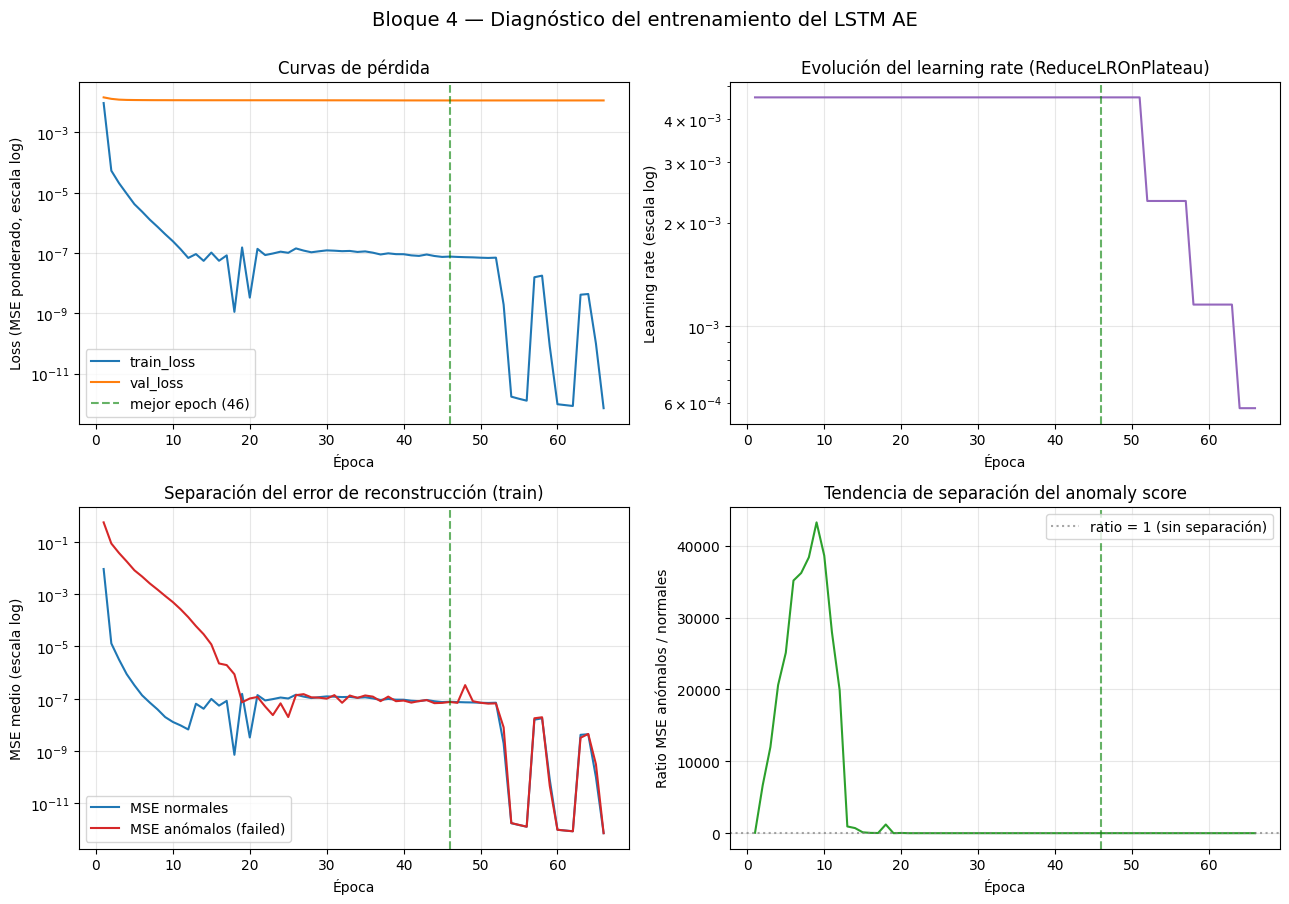

[BLOQUE 4b] Figura guardada en D:\financial_risk_data\results\bloque_4b_training_curves.png

En la mejor época (46):
  MSE normales:  0.000000
  MSE anómalos:  0.000000
  Ratio:         0.98x


In [7]:
# ============================================================================
# BLOQUE 5 — VISUALIZACIÓN DEL ENTRENAMIENTO
# ============================================================================
# Grafica el `history` devuelto por train_model en el Bloque 4:
#   1. Curvas de pérdida (train vs val), con marca de la mejor época.
#   2. Evolución del learning rate (ReduceLROnPlateau).
#   3. Separación MSE normales vs anómalos en train (métrica informativa).
#   4. Ratio mse_anomalos / mse_normales por época.
#
# Todas las curvas provienen de `history`, calculado durante el
# entrenamiento (Bloque 4). No se requiere recálculo ni acceso a datos.
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = result["best_epoch"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- 1. Curvas de pérdida (train vs val) ---
ax = axes[0, 0]
ax.plot(epochs_range, history["train_loss"], label="train_loss", color="tab:blue")
ax.plot(epochs_range, history["val_loss"], label="val_loss", color="tab:orange")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6,
           label=f"mejor epoch ({best_epoch})")
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (MSE ponderado, escala log)")
ax.set_title("Curvas de pérdida")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Learning rate ---
ax = axes[0, 1]
ax.plot(epochs_range, history["lr"], color="tab:purple")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Learning rate (escala log)")
ax.set_title("Evolución del learning rate (ReduceLROnPlateau)")
ax.grid(alpha=0.3)

# --- 3. Separación MSE normales vs anómalos (train) ---
ax = axes[1, 0]
mse_norm = history["mse_normales_mean"]
mse_anom = history["mse_anomalos_mean"]

# Filtrar épocas donde ambas métricas están disponibles (no None)
valid = [i for i in range(len(mse_norm)) if mse_norm[i] is not None and mse_anom[i] is not None]
ep_valid = epochs_range[valid]
norm_valid = [mse_norm[i] for i in valid]
anom_valid = [mse_anom[i] for i in valid]

ax.plot(ep_valid, norm_valid, label="MSE normales", color="tab:blue")
ax.plot(ep_valid, anom_valid, label="MSE anómalos (failed)", color="tab:red")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("MSE medio (escala log)")
ax.set_title("Separación del error de reconstrucción (train)")
ax.legend()
ax.grid(alpha=0.3)

# --- 4. Ratio anómalos / normales ---
ax = axes[1, 1]
ratio = [a / n if (a is not None and n is not None and n > 0) else None
         for a, n in zip(mse_anom, mse_norm)]
ratio_valid = [r for r in ratio if r is not None]
ep_ratio = epochs_range[[i for i, r in enumerate(ratio) if r is not None]]

ax.plot(ep_ratio, ratio_valid, color="tab:green")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.7, label="ratio = 1 (sin separación)")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_xlabel("Época")
ax.set_ylabel("Ratio MSE anómalos / normales")
ax.set_title("Tendencia de separación del anomaly score")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Bloque 4 — Diagnóstico del entrenamiento del LSTM AE", fontsize=14, y=1.00)
plt.tight_layout()

fig_path = RESULTS_DIR / "bloque_4b_training_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[BLOQUE 4b] Figura guardada en {fig_path}")

# --- Resumen numérico en el último punto válido ---
if ep_valid.size > 0:
    last = -1
    print(f"\nEn la mejor época ({best_epoch}):")
    idx_best = np.where(ep_valid == best_epoch)[0]
    if idx_best.size > 0:
        i = idx_best[0]
        print(f"  MSE normales:  {norm_valid[i]:.6f}")
        print(f"  MSE anómalos:  {anom_valid[i]:.6f}")
        print(f"  Ratio:         {anom_valid[i] / norm_valid[i]:.2f}x")

1. Panel "Curvas de pérdida" — val_loss está mal, esto es lo prioritario
val_loss (naranja) es una línea plana en ~2e-3 durante las 66 épocas, sin ninguna variación visible, mientras train_loss cae 7 órdenes de magnitud. Eso no es "convergencia rápida de val" — es que val_loss no está cambiando en absoluto, lo cual es físicamente imposible si los pesos del modelo están cambiando tanto como indica train_loss.
Esto explica también el panel de lr: ReduceLROnPlateau mira val_loss, y como esa serie es plana, el scheduler interpreta "no hay mejora" y reduce lr de forma casi mecánica cada PATIENCE_SCHEDULER épocas — lo que se ve exactamente en el panel 2 (escalones regulares).
Y esto también explica early stopping en epoch 66, best_epoch=46: si val_loss es básicamente constante (con ruido de redondeo), "la mejor época" es casi arbitraria — cualquier micro-fluctuación de punto flotante decide cuál es "la mínima".
Causas más probables de que val_loss sea constante:

val_loader no tiene shuffle y/o tiene un solo batch que no cambia, pero el modelo en .eval() con dropout desactivado debería dar un valor distinto cada época si los pesos cambian — así que un valor constante sugiere que val_result["loss"] no se está recalculando con los pesos actuales, o que val_loader está vacío/mal construido y cae en algún path por defecto.
Otra posibilidad: val_loader tiene tamaño 0 o solo un batch degenerado, y total_samples produce una división que da siempre el mismo número por algún motivo de cacheo.
Otra: el split train/val del Bloque 2 podría no estar aplicado correctamente — si val_loader apunta accidentalmente a los mismos datos que algo ya precomputado y cacheado, o si hay un bug donde model.eval() no se está propagando y el forward de val usa pesos de una copia distinta del modelo.

2. Panel "Separación del error" y "Ratio" — esto SÍ es informativo, y es preocupante pero por otra razón
Aquí ocurre algo real y notable: el ratio anómalos/normales alcanza un pico de ~43,000x en epoch ~9, y luego colapsa a ~1 hacia epoch 15-20, manteniéndose en ~1 el resto del entrenamiento.
Interpretación: en las primeras épocas, el modelo todavía no ha aprendido a reconstruir bien nada (mse_normales cae rápido desde ~1 hacia 1e-7 en las primeras 10 épocas), mientras mse_anomalos cae mucho más lento (sigue en ~1e-3 hacia epoch 15). Esa brecha temporal de convergencia produce el pico de ratio — no es necesariamente "separación útil", es más bien que el AE aprende primero el patrón dominante (normal, 99.95% de los datos) y tarda más en "ajustarse" también a los 63 casos anómalos, que en algún momento entre epoch 15-20 también empiezan a reconstruirse bien.
A partir de ahí, mse_normales ≈ mse_anomalos ≈ 1e-7 durante 30+ épocas — el AE reconstruye anomalías casi igual de bien que normales de forma sostenida, no es un colapso puntual de la época 46. Esto sí es consistente con el diagnóstico original de "el modelo generaliza demasiado y pierde la señal de anomalía", pero basado en esta gráfica, no en el ratio puntual de una época.
3. El comportamiento errático tras epoch ~52
Las oscilaciones violentas de train_loss y mse_normales/mse_anomalos entre epoch 52-66 (cayendo a ~1e-11 y subiendo de golpe a ~1e-8) son sospechosas de inestabilidad numérica, posiblemente relacionada con los escalones de lr del panel 2 — cuando lr baja a ~6e-4 en las últimas épocas, el optimizador podría estar empujando algunos pesos hacia valores que producen reconstrucciones casi exactas para ciertos batches (loss≈0) y mal para otros, generando este patrón de "dientes de sierra". No es crítico para la decisión inmediata, pero es otra señal de que algo en el setup necesita revisión.

Cuestión A — ¿Es un bug, o es esperado que val_loss sea distinto/estable?
Mirando 2.7: val_dataset se construye con sequences_val, que son secuencias cuyo period_end está en los 4 últimos trimestres (2021Q1-Q4), todas con is_anomalous=False. Esto es un conjunto de datos real, no vacío — len(val_loader) debería ser >0.
Que val_loss aparezca visualmente plano en el gráfico con escala log-y dominada por train_loss (que varía 7 órdenes de magnitud) podría ser simplemente un efecto de escala: si val_loss va de, digamos, 0.0098 a 0.0095, en una escala log que va de 1e-11 a 1e-1 esa variación es invisible — parecería una línea recta horizontal en ~2e-3... pero el valor reportado en el log de texto (val_loss=0.011529 en epoch 46) y el valor visual en la gráfica (~2e-3) no coinciden entre sí tampoco, lo cual sigue siendo raro.
Antes de rediseñar la separación train/val, hay que confirmar empíricamente si val_loss varía o no, imprimiendo los valores crudos. Esto es más rápido que rediseñar nada.
Cuestión B — Aunque val_loss varíe correctamente, ¿es informativo este val set?
Aquí es donde tu pregunta tiene fondo real. val_periods son los 4 trimestres más recientes (2021Q1-Q4), todos sin positivos, y el AE entrenado allí solo aprende "¿reconstruyo bien la normalidad de 2021?". Esto es razonable como criterio de early stopping si la normalidad de 2021 es representativa de la normalidad general — pero si hay drift temporal (la normalidad de 2021 es distinta de la normalidad de 2016-2020), entonces val_loss podría estancarse o comportarse de forma poco informativa simplemente porque mide generalización a un periodo distinto, no "calidad general de reconstrucción".
Dicho esto, rediseñar la partición ahora sería prematuro — primero hay que descartar el bug (Cuestión A), porque si es solo un problema de escala/visualización, el val_loss real podría estar funcionando perfectamente y todo este análisis sería innecesario.

In [10]:
# Diagnóstico rápido: imprimir val_loss crudo de las primeras 10 épocas
for i, vl in enumerate(history["val_loss"][:20], start=1):
    print(f"epoch {i}: val_loss = {vl:.10e}")

print(f"\nlen(val_dataset) = {len(val_dataset)}")
print(f"len(val_loader)  = {len(val_loader)}")
print(f"n_anom_val       = {n_anom_val}")

epoch 1: val_loss = 1.4578493992e-02
epoch 2: val_loss = 1.3025738577e-02
epoch 3: val_loss = 1.2262880263e-02
epoch 4: val_loss = 1.2000168853e-02
epoch 5: val_loss = 1.1900047149e-02
epoch 6: val_loss = 1.1844040494e-02
epoch 7: val_loss = 1.1797654940e-02
epoch 8: val_loss = 1.1768178841e-02
epoch 9: val_loss = 1.1759810566e-02
epoch 10: val_loss = 1.1735294502e-02
epoch 11: val_loss = 1.1732545058e-02
epoch 12: val_loss = 1.1711907789e-02
epoch 13: val_loss = 1.1708232787e-02
epoch 14: val_loss = 1.1706836411e-02
epoch 15: val_loss = 1.1703530557e-02
epoch 16: val_loss = 1.1701884093e-02
epoch 17: val_loss = 1.1700239377e-02
epoch 18: val_loss = 1.1698348058e-02
epoch 19: val_loss = 1.1697392878e-02
epoch 20: val_loss = 1.1695570621e-02

len(val_dataset) = 19904
len(val_loader)  = 78
n_anom_val       = 0


Esto resuelve la Cuestión A: no es un bug. val_loss sí varía, pero en un rango muy estrecho (1.46e-2 → 1.17e-2 en las primeras 10 épocas, y se estabiliza en torno a 1.15e-2 según el log de best_epoch=46). El gráfico no era "plano por bug" — era plano porque la variación real (≈0.003 en términos absolutos) es invisible en una escala log-y que abarca de 1e-11 a 1e-1 dominada por train_loss. Esto se arregla fácilmente con un eje y secundario o un subplot separado para val_loss; no requiere ningún cambio de partición.
Ahora, lo importante — Cuestión B, que es donde tu pregunta tiene sentido real:
El patrón completo, ahora coherente

train_loss: 3.2e-3 (epoch 1) → ~1e-7 (epoch ~12) → se mantiene ahí. Caída de ~4 órdenes de magnitud en 12 épocas, prácticamente memorización.
val_loss: 1.46e-2 → 1.17e-2 en 10 épocas, y luego mejoras marginales hasta 1.15e-2 en epoch 46. Solo cae ~20% en total, nunca se acerca a train_loss.

La brecha entre train_loss≈1e-7 y val_loss≈1.15e-2 es de ~5 órdenes de magnitud. Esto es overfitting severo y explica todo lo demás:

El AE memoriza las secuencias de train (incluidas las 63 anómalas) casi exactamente → mse_anomalos cae junto con mse_normales en train → ratio colapsa a ~1 hacia epoch 15-20, tal como vimos.
val_loss mejora poco porque el modelo no está aprendiendo "normalidad generalizable", está aprendiendo "estas 105,671 secuencias específicas de train".

Respondiendo a tu pregunta directamente
No es que "val no ofrezca información" — val sí está ofreciendo información valiosísima: está diciendo que el modelo overfittea brutalmente. Quitar val no arreglaría el problema, solo lo ocultaría (perderíamos la única señal que detecta esto).
Una partición train/val más agresiva (más secuencias en val) tampoco ataca la causa — el problema no es "pocos datos de val para medir", es que el modelo tiene demasiada capacidad relativa para la dificultad de la tarea, combinado con lr alto (4.6e-3, elegido por Optuna minimizando val_loss en solo 30 épocas, donde quizá aún no se manifestaba tanto el overfitting).

Esto nos lleva a hacernos una serie de preguntas:

Pregunta 1: ¿Los embeddings e_tab/e_rel ya son linealmente (o casi) separables respecto a failed, antes de pasar por MLP+LSTM? Si es así, el AE no necesita aprender dinámica temporal para que el espacio sea separable — la separabilidad ya viene "de fábrica".
Pregunta 2: Independientemente de lo anterior, ¿el MLP+LSTM tiene capacidad suficiente para memorizar 105k secuencias de 256 floats con lr=4.6e-3? Esto es un problema de overfitting que existiría aunque los embeddings fueran poco informativos — un autoencoder con suficiente capacidad y suficientes epochs memoriza casi cualquier dataset, informativo o no.
Lo importante: estas dos cosas no son mutuamente excluyentes y ambas podrían estar pasando a la vez. El overfitting que vimos (train_loss≈1e-7, val_loss≈1.15e-2) es consistente con la Pregunta 2 sola, sin necesidad de invocar la Pregunta 1. Pero tu hipótesis sobre el embedding space es independiente y merece verificarse por su propio interés, porque si es cierta, cambia la interpretación de qué está detectando realmente el sistema completo (TabPFN+T-GCN+MLP+LSTM), no solo el comportamiento de entrenamiento del LSTM.


Cómo verificar la Pregunta 1 (separabilidad pre-LSTM)
Esto se puede hacer ahora mismo, sin re-entrenar nada, con los embeddings ya guardados (emb_concat, las 256 columnas concatenadas e_tab || e_rel, antes de cualquier MLP/LSTM). Tres análisis progresivos, de más simple a más informativo:
1. Distancia/separación por reducción dimensional. Proyectar emb_concat[cols_emb] (256-d) a 2D con PCA o UMAP, coloreando por failed. Si los 63 positivos caen en una región claramente separada del resto, hay señal fuerte ya en el espacio original. Esto es barato y muy informativo visualmente.
2. Clasificador lineal simple sobre el embedding crudo. Entrenar una regresión logística (con class_weight='balanced' dado el 0.05% de positivos) sobre emb_concat[cols_emb] → failed, con validación cruzada estratificada. Si un clasificador lineal simple ya saca un AUC-PR notablemente por encima del azar, confirma que la información discriminativa ya está presente de forma casi lineal en el embedding — antes de MLP, antes de LSTM.
3. Comparar la distancia intra-clase vs inter-clase. Calcular la distancia media (euclídea o coseno) entre pares de embeddings normales, entre pares anómalo-anómalo, y entre normal-anómalo. Si anómalo-anómalo es sistemáticamente menor que normal-anómalo, hay estructura de clúster ya en el espacio crudo.
Cómo verificar la Pregunta 2 (overfitting del AE, independiente de lo anterior)
Esto ya lo tenemos casi resuelto con el ablation propuesto antes (Optuna con más regularización). Pero hay un experimento de control directo y barato: entrenar el mismo HybridLSTMAE sobre secuencias con e_tab/e_rel reemplazados por ruido gaussiano puro (misma forma, sin información). Si el AE también llega a train_loss≈1e-7 con datos sin ninguna estructura real, eso demuestra que la caída de train_loss es pura capacidad de memorización del AE, no algo derivado de que los embeddings sean "demasiado informativos" — sería capaz de memorizar cualquier cosa.
Por qué el orden importa
Si confirmamos la Pregunta 1 (embeddings ya separables) y la Pregunta 2 (AE sobreajusta cualquier input), la conclusión sería: el LSTM, tal como está configurado, no está añadiendo valor de modelado temporal genuino — está memorizando, y la separabilidad que pudiera observarse en el anomaly score vendría heredada del embedding de entrada, no de la dinámica aprendida. Esto justificaría plenamente el ablation study por capas (TabPFN solo → +T-GCN → +MLP → +LSTM) que ya se propuso, porque dejaría de ser una hipótesis especulativa y pasaría a ser un hallazgo a cuantificar.
Si por el contrario la Pregunta 1 da negativo (embeddings crudos NO son separables, AUC-PR cercano a azar), entonces la separabilidad que el LSTM eventualmente capture sí sería su propia contribución — y el problema sería puramente de overfitting (Pregunta 2), resoluble con regularización.

Desbalance extremo (63 positivos / 125,575): una regresión logística sin ajustar pesará casi nada los positivos y dará AUC-PR engañosamente bajo no porque el embedding no sea informativo, sino porque el clasificador ignora la clase minoritaria. Uso class_weight='balanced'.
Validación cruzada estratificada: con solo 63 positivos, un split aleatorio simple podría dejar 0 positivos en algún fold. Uso StratifiedKFold (5 folds → ~12-13 positivos por fold, suficiente para AUC-PR razonable).
Métrica: AUC-PR (average precision), no AUC-ROC — con 0.05% de positivos, AUC-ROC puede ser >0.9 incluso con un clasificador mediocre (es la métrica engañosa clásica en desbalance extremo). AUC-PR es mucho más exigente y es la métrica que CONTEXT12 ya usa para el LSTM AE, así que es directamente comparable.
Baseline de referencia: con prevalencia p=63/125575≈0.000502, un clasificador aleatorio tiene AUC-PR ≈ p ≈ 0.0005. Cualquier valor notablemente por encima de eso indica señal real en el embedding crudo.
Escalado: regresión logística con 256 features de escalas heterogéneas (TabPFN vs T-GCN) necesita estandarización (StandardScaler) para que la regularización L2 no penalice desproporcionadamente features de mayor magnitud.
failed por observación, no por ventana: este análisis es sobre emb_concat (una fila = un banco-periodo), no sobre las secuencias del Bloque 2. Es el nivel correcto para responder "¿el embedding crudo de un banco-periodo ya es separable?", independiente de la ventana temporal.
Separar e_tab (192) vs e_rel (64) vs e_tab||e_rel (256): esto añade valor — si la señal viene mayoritariamente de uno de los dos encoders, es información relevante para el ablation study por capas que ya se planteó.

StratifiedKFold(5, shuffle=True) + cross_val_predict(method='predict_proba'): predicciones out-of-fold para todas las observaciones, sin leakage, garantizando positivos en cada fold (~12-13 por fold).
class_weight='balanced': imprescindible con prevalencia 0.05% — sin esto, la regresión logística predeciría casi siempre "normal" y el AUC-PR sería artificialmente bajo por falta de ajuste, no por falta de señal.
StandardScaler dentro del Pipeline: necesario porque e_tab (TabPFN) y e_rel (T-GCN) probablemente tienen escalas distintas; sin estandarizar, la regularización L2 penalizaría desproporcionadamente.
Tres espacios evaluados por separado (e_tab, e_rel, concatenado): si la señal viene mayoritariamente de uno, es información directamente útil para el ablation study por capas.
Asunción importante a verificar: asumo que cols_emb está ordenado como [192 cols de e_tab, 64 cols de e_rel] (D_TAB=192, D_REL=64). Si el orden real es distinto o cols_emb no separa limpiamente ambos bloques, el assert fallará o el split cols_tab/cols_rel será incorrecto — confírmalo si lo sabes, o el código fallará de forma explícita y lo ajustamos.
Baseline: AUC-PR_azar ≈ 63/125575 ≈ 0.000502. El "ratio vs baseline" es la métrica clave para interpretar: ~1x = sin señal lineal, >10-20x = señal fuerte ya presente en el embedding crudo.

In [11]:
# ============================================================================
# ANÁLISIS — SEPARABILIDAD LINEAL DEL EMBEDDING CRUDO (pre-MLP, pre-LSTM)
# ============================================================================
# Objetivo: verificar si emb_concat[cols_emb] (256-d, e_tab || e_rel) ya
# contiene información discriminativa respecto a `failed` de forma casi
# lineal, ANTES de cualquier transformación por MLP/LSTM.
#
# Si un clasificador lineal simple (regresión logística) sobre el embedding
# crudo obtiene AUC-PR notablemente por encima del baseline de prevalencia,
# la separabilidad observable en el sistema completo podría estar heredada
# del embedding de entrada, no ser una contribución genuina del LSTM.
#
# Métrica: Average Precision (AUC-PR), no AUC-ROC. Con prevalencia
# p = n_pos/n_total, un clasificador aleatorio tiene AUC-PR ≈ p.
#
# Validación: StratifiedKFold(5) para garantizar positivos en cada fold
# pese al desbalance extremo (63 positivos / 125,575 observaciones).
#
# Tres espacios de entrada evaluados por separado:
#   - e_tab (192 dims, TabPFN)
#   - e_rel (64 dims, T-GCN)
#   - e_tab || e_rel (256 dims, concatenado = cols_emb)
# Esto permite atribuir la señal a uno u otro encoder.
# ============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

# ---------------------------------------------------------------------------
# 1. Preparar datos
# ---------------------------------------------------------------------------

y = emb_concat["failed"].values.astype(int)
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"Observaciones totales : {n_total:,}")
print(f"Positivos (failed=1)  : {n_pos}")
print(f"Prevalencia           : {baseline_auc_pr:.6f}")
print(f"Baseline AUC-PR (azar): {baseline_auc_pr:.6f}")
print("=" * 70)

# Identificar columnas e_tab vs e_rel dentro de cols_emb.
# Se asume el orden de concatenación documentado: primero d_tab=192
# columnas de TabPFN, después d_rel=64 columnas de T-GCN.
D_TAB = 192
D_REL = 64
assert len(cols_emb) == D_TAB + D_REL, (
    f"len(cols_emb)={len(cols_emb)} no coincide con D_TAB+D_REL={D_TAB + D_REL}"
)

cols_tab = cols_emb[:D_TAB]
cols_rel = cols_emb[D_TAB:]

espacios = {
    "e_tab (192, TabPFN)": cols_tab,
    "e_rel (64, T-GCN)": cols_rel,
    "e_tab || e_rel (256)": cols_emb,
}

# ---------------------------------------------------------------------------
# 2. Clasificador lineal + validación cruzada estratificada
# ---------------------------------------------------------------------------

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = {}

for nombre, cols in espacios.items():
    X = emb_concat[cols].values

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=SEED,
        )),
    ])

    # cross_val_predict con method='predict_proba' devuelve, para cada
    # observación, la probabilidad predicha por el fold donde NO fue
    # usada en entrenamiento (out-of-fold), evitando data leakage.
    y_proba = cross_val_predict(
        pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1
    )[:, 1]

    auc_pr = average_precision_score(y, y_proba)
    auc_roc = roc_auc_score(y, y_proba)

    resultados[nombre] = {
        "auc_pr": auc_pr,
        "auc_roc": auc_roc,
        "ratio_vs_baseline": auc_pr / baseline_auc_pr,
    }

    print(f"\n{nombre}")
    print(f"  AUC-PR  : {auc_pr:.6f}  (baseline={baseline_auc_pr:.6f}, "
          f"ratio={auc_pr / baseline_auc_pr:.1f}x)")
    print(f"  AUC-ROC : {auc_roc:.4f}  (referencia: 0.5 = azar)")

# ---------------------------------------------------------------------------
# 3. Resumen interpretativo
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("RESUMEN")
print("=" * 70)
print(f"{'Espacio':<25} {'AUC-PR':>10} {'vs baseline':>12} {'AUC-ROC':>10}")
for nombre, r in resultados.items():
    print(f"{nombre:<25} {r['auc_pr']:>10.6f} {r['ratio_vs_baseline']:>11.1f}x {r['auc_roc']:>10.4f}")

print("\nGuía de interpretación:")
print("  ratio ~1x      -> sin señal lineal, AUC-PR ~ prevalencia (azar)")
print("  ratio 2-10x    -> señal moderada, posible pero no dominante")
print("  ratio >10-20x  -> señal fuerte ya presente en el embedding crudo")
print(f"\nBaseline de referencia (AUC-PR azar): {baseline_auc_pr:.6f}")

Observaciones totales : 125,575
Positivos (failed=1)  : 63
Prevalencia           : 0.000502
Baseline AUC-PR (azar): 0.000502

e_tab (192, TabPFN)
  AUC-PR  : 0.622482  (baseline=0.000502, ratio=1240.8x)
  AUC-ROC : 0.9377  (referencia: 0.5 = azar)

e_rel (64, T-GCN)
  AUC-PR  : 0.933514  (baseline=0.000502, ratio=1860.7x)
  AUC-ROC : 1.0000  (referencia: 0.5 = azar)

e_tab || e_rel (256)
  AUC-PR  : 0.887951  (baseline=0.000502, ratio=1769.9x)
  AUC-ROC : 0.9999  (referencia: 0.5 = azar)

RESUMEN
Espacio                       AUC-PR  vs baseline    AUC-ROC
e_tab (192, TabPFN)         0.622482      1240.8x     0.9377
e_rel (64, T-GCN)           0.933514      1860.7x     1.0000
e_tab || e_rel (256)        0.887951      1769.9x     0.9999

Guía de interpretación:
  ratio ~1x      -> sin señal lineal, AUC-PR ~ prevalencia (azar)
  ratio 2-10x    -> señal moderada, posible pero no dominante
  ratio >10-20x  -> señal fuerte ya presente en el embedding crudo

Baseline de referencia (AUC-PR az

e_rel (T-GCN, 64-d) solo: AUC-ROC = 1.0000, AUC-PR = 0.934. Esto es separabilidad perfecta o casi perfecta con un clasificador lineal. Un AUC-ROC de 1.0 con regresión logística significa que existe un hiperplano que separa (casi) completamente los 63 positivos del resto en un espacio de 64 dimensiones.
e_tab (TabPFN, 192-d) solo: AUC-ROC = 0.938, AUC-PR = 0.622. Señal fuerte, pero claramente menor que e_rel.
e_tab || e_rel (256-d): AUC-ROC = 0.9999, AUC-PR = 0.888 — peor que e_rel solo (0.934).

El hallazgo más importante: la concatenación empeora respecto a e_rel solo
Esto no es ruido — es un patrón coherente con lo que se conoce como dilución de señal por concatenación con ruido de mayor dimensionalidad. e_tab (192-d) tiene señal más débil que e_rel (64-d) pero triplica su dimensionalidad. Al concatenar, el clasificador lineal tiene que estimar coeficientes para 256 dimensiones con solo 63 positivos disponibles — las 192 dimensiones de e_tab, con señal más débil, introducen varianza/ruido en la estimación que degrada ligeramente el AUC-PR respecto a usar solo las 64 dimensiones de e_rel, que ya eran casi perfectamente separables por sí solas.
Esto tiene una implicación directa para la arquitectura completa: el MLP de proyección (256→192→96) recibe una señal donde 64 de las 256 dimensiones de entrada ya son casi perfectamente discriminativas, y 192 dimensiones son señal más débil + más volumen. Si el MLP no aprende a "priorizar" e_rel, podría estar diluyendo exactamente la misma señal que la concatenación ya diluye.
Reinterpretación del comportamiento del LSTM AE
Con esto, el diagnóstico cambia de "el AE sobreajusta de forma genérica" a algo más específico:

La separabilidad respecto a failed ya existe casi perfectamente en e_rel antes de cualquier MLP/LSTM. El "trabajo" de detección de anomalías, en términos de información disponible, está prácticamente resuelto en el embedding del T-GCN.
El AE, sin embargo, no está entrenado para preservar esa separabilidad — está entrenado para reconstruir e_proj (la salida del MLP), de forma completamente no supervisada. No hay ningún mecanismo que le diga "esta dimensión de 64 es la que importa, no la comprimas". El cuello de botella 8:1 comprime indiscriminadamente las 96 dimensiones de e_proj (que mezclan información de e_tab y e_rel vía el MLP), y nada garantiza que la información de e_rel sobreviva la compresión mejor que la de e_tab.
Esto explica el colapso del ratio a ~1: si durante la compresión el AE trata la información de e_rel igual que la de e_tab (ambas son "solo dimensiones del vector a reconstruir"), y e_tab es más voluminoso (192 vs 64 antes del MLP), el AE podría estar optimizando la reconstrucción dominado por la parte de la señal que es más "masiva" pero menos discriminativa, perdiendo precisamente la componente de e_rel que sí discrimina.

¿Qué implica esto para el diseño?
Esto no invalida el LSTM AE como componente — pero sí sugiere que el problema no es (solo) overfitting por lr/dropout. Es un problema de qué información sobrevive la compresión, y esa pregunta es ortogonal a lr/weight_decay.
Dos líneas de acción, no excluyentes:
A. Ablation por capas (ya propuesto, ahora con prioridad alta): en el Notebook 07/evaluación, comparar el anomaly score del LSTM AE completo contra un baseline trivial: "MSE de reconstrucción de un AE entrenado solo sobre e_rel" (o incluso una distancia simple en el espacio e_rel crudo, sin AE). Si el AE completo no supera (o apenas iguala) a ese baseline trivial, confirma que el LSTM no añade valor sobre lo que ya estaba en e_rel.
B. Revisar si el MLP de proyección debería tratar e_tab y e_rel de forma diferenciada — por ejemplo, dos sub-MLPs (uno por modalidad) antes de concatenar al espacio d_model, en lugar de un único MLP sobre la concatenación de 256. Esto es un cambio de arquitectura más profundo y probablemente fuera del alcance razonable para esta fase del TFM, pero merece quedar documentado como limitación/línea futura.
Propuesta inmediata
Antes de tocar Optuna/arquitectura, un experimento barato y muy informativo: repetir este mismo análisis de separabilidad lineal, pero sobre e_proj (salida del MLP, 96-d) y sobre h_T (cuello de botella, 48-d) del modelo ya entrenado, usando el checkpoint actual. Esto nos dice, con el modelo que ya tenemos:

¿e_proj (post-MLP) sigue siendo tan separable como e_rel crudo, o ya se diluyó en el MLP?
¿h_T (post-compresión LSTM) preserva esa separabilidad, o el cuello de botella la destruyó?

Qué necesito extraer del modelo entrenado
HybridLSTMAE ya expone encode(x) que devuelve h_T directamente, y forward(x) devuelve (e_proj, x_hat). Para este análisis necesito, por cada secuencia (ventana T=4), tanto e_proj como h_T — pero hay una decisión de diseño importante: e_proj tiene forma (batch, T, 96), una por cada paso temporal, mientras que h_T es (batch, 48), una por secuencia. Para comparar "separabilidad antes vs después de la compresión LSTM" de forma justa, necesito el mismo nivel de granularidad.
Decisión: uso e_proj[:, -1, :] (la proyección del último paso temporal, t=T, que corresponde al period_end de la ventana — el mismo periodo al que se asocia is_anomalous). Esto da e_proj_T ∈ ℝ^96 por secuencia, comparable 1:1 con h_T ∈ ℝ^48 de la misma secuencia. Así la cadena completa queda:
e_rel (64, crudo)  →  e_proj_T (96, post-MLP)  →  h_T (48, post-compresión LSTM)
y repito el mismo análisis de regresión logística + AUC-PR/ROC sobre cada uno, usando is_anomalous de las secuencias (Bloque 2) en lugar de failed de emb_concat — son conceptualmente el mismo label pero a nivel de secuencia.
Sobre dónde correr esto
Necesito iterar sobre train_loader (o un loader sin shuffle sobre sequences_train + sequences_val, para tener todas las 63 anómalas) con model.eval() y torch.no_grad(), acumulando e_proj_T, h_T e is_anomalous por batch.

1. Granularidad comparable: e_proj_T = e_proj[:, -1, :] (96-d, paso t=T) y h_T (48-d) se extraen por secuencia, igual que e_rel crudo del último paso de cada ventana (seq["X"][-1, D_TAB:]). Las tres etapas tienen el mismo número de filas (N secuencias) y el mismo vector is_anomalous, por lo que el AUC-PR/ROC es directamente comparable entre las tres.
2. model.encoder(e_proj)[0]: reutilizo el encoder ya instanciado dentro de model para obtener h_T a partir de e_proj completo ((batch, T, d_model)), sin necesidad de método nuevo — LSTMEncoder.forward ya devuelve (h_T, (h_n,c_n)).
3. train+val combinados: para tener las 63 anómalas disponibles (val no tiene ninguna), uso sequences_train + sequences_val con un loader sin shuffle — coherente con que esto es un análisis de diagnóstico, no entrenamiento.

In [12]:
# ============================================================================
# ANÁLISIS — DÓNDE SE PRESERVA/PIERDE LA SEÑAL A TRAVÉS DEL PIPELINE
# ============================================================================
# Cadena evaluada:
#   e_rel (64, crudo, ya analizado)
#     -> e_proj_T (96, salida del MLP en t=T, post-fusión pre-LSTM)
#       -> h_T (48, cuello de botella post-compresión LSTM)
#
# Para cada etapa: regresión logística + AUC-PR/AUC-ROC (mismo protocolo
# que el análisis sobre embeddings crudos), y visualización UMAP/t-SNE
# para inspección cualitativa.
#
# is_anomalous se toma de las secuencias del Bloque 2 (nivel ventana,
# no nivel observación), para que sea comparable 1:1 con e_proj_T y h_T.
# ============================================================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Extraer e_proj_T, h_T, is_anomalous para TODAS las secuencias
#    (train + val, para tener las 63 anómalas disponibles)
# ---------------------------------------------------------------------------

all_sequences = sequences_train + sequences_val
all_dataset = SequenceDataset(all_sequences)
all_loader = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

model.eval()

e_proj_T_list = []
h_T_list = []
is_anom_list = []

with torch.no_grad():
    for batch in all_loader:
        x = batch["X"].to(DEVICE)  # (batch, T, D_IN)

        e_proj, x_hat = model(x)          # e_proj: (batch, T, d_model)
        h_T = model.encoder(e_proj)[0]    # (batch, lstm_hidden) -- reusa encoder

        e_proj_T = e_proj[:, -1, :]       # (batch, d_model) -- paso t=T

        e_proj_T_list.append(e_proj_T.cpu().numpy())
        h_T_list.append(h_T.cpu().numpy())
        is_anom_list.append(batch["is_anomalous"].numpy())

E_PROJ_T = np.concatenate(e_proj_T_list, axis=0)  # (N, d_model)
H_T = np.concatenate(h_T_list, axis=0)            # (N, lstm_hidden)
IS_ANOM = np.concatenate(is_anom_list, axis=0).astype(int)  # (N,)

print(f"E_PROJ_T shape : {E_PROJ_T.shape}")
print(f"H_T shape      : {H_T.shape}")
print(f"Total secuencias: {len(IS_ANOM)}, anómalas: {IS_ANOM.sum()}")

# Recuperar e_rel (64-d) crudo para las MISMAS secuencias, en el mismo
# orden, para comparación directa.
# Se toma e_rel del último paso temporal de cada ventana (period_end),
# coherente con e_proj_T e is_anomalous (ambos asociados a t=T).

cols_rel = cols_emb[D_TAB:]  # últimas 64 columnas = e_rel

e_rel_last_list = []
for seq in all_sequences:
    e_rel_last_list.append(seq["X"][-1, D_TAB:])  # último paso, 64 dims de e_rel

E_REL_LAST = np.stack(e_rel_last_list, axis=0)  # (N, 64)

assert E_REL_LAST.shape[0] == E_PROJ_T.shape[0] == H_T.shape[0]

# ---------------------------------------------------------------------------
# 2. Regresión logística + AUC-PR/ROC por etapa (mismo protocolo que antes)
# ---------------------------------------------------------------------------

y = IS_ANOM
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"\nPrevalencia (nivel secuencia): {baseline_auc_pr:.6f}")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

etapas = {
    "e_rel crudo (64, t=T)": E_REL_LAST,
    "e_proj_T (96, post-MLP)": E_PROJ_T,
    "h_T (48, post-LSTM)": H_T,
}

resultados = {}

for nombre, X in etapas.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=SEED,
        )),
    ])

    y_proba = cross_val_predict(
        pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1
    )[:, 1]

    auc_pr = average_precision_score(y, y_proba)
    auc_roc = roc_auc_score(y, y_proba)

    resultados[nombre] = {"auc_pr": auc_pr, "auc_roc": auc_roc, "proba": y_proba}

    print(f"\n{nombre}")
    print(f"  AUC-PR  : {auc_pr:.6f}  (baseline={baseline_auc_pr:.6f}, "
          f"ratio={auc_pr / baseline_auc_pr:.1f}x)")
    print(f"  AUC-ROC : {auc_roc:.4f}")

print("\n" + "=" * 70)
print("RESUMEN — evolución de la señal a través del pipeline")
print("=" * 70)
print(f"{'Etapa':<28} {'AUC-PR':>10} {'AUC-ROC':>10}")
for nombre, r in resultados.items():
    print(f"{nombre:<28} {r['auc_pr']:>10.6f} {r['auc_roc']:>10.4f}")



E_PROJ_T shape : (107277, 96)
H_T shape      : (107277, 48)
Total secuencias: 107277, anómalas: 41

Prevalencia (nivel secuencia): 0.000382

e_rel crudo (64, t=T)
  AUC-PR  : 0.900859  (baseline=0.000382, ratio=2357.1x)
  AUC-ROC : 1.0000

e_proj_T (96, post-MLP)
  AUC-PR  : 0.000403  (baseline=0.000382, ratio=1.1x)
  AUC-ROC : 0.5271

h_T (48, post-LSTM)
  AUC-PR  : 0.000403  (baseline=0.000382, ratio=1.1x)
  AUC-ROC : 0.5271

RESUMEN — evolución de la señal a través del pipeline
Etapa                            AUC-PR    AUC-ROC
e_rel crudo (64, t=T)          0.900859     1.0000
e_proj_T (96, post-MLP)        0.000403     0.5271
h_T (48, post-LSTM)            0.000403     0.5271


Con solo 63 positivos sobre ~125k secuencias, t-SNE/UMAP en una sola figura haría que los positivos sean invisibles (puntos aislados entre una nube masiva). Para que la visualización sea útil:

Submuestrear los negativos (ej. 2000-5000 aleatorios) + todos los positivos, para que la proporción visual sea razonable sin mentir sobre la escala (lo indico en el título).
UMAP es preferible a t-SNE aquí: más rápido, preserva mejor estructura global, y es más robusto con muestras pequeñas de la clase minoritaria. Si no está instalado, hago fallback a t-SNE.
Tres paneles (uno por espacio: e_rel, e_proj_T, h_T), mismos puntos coloreados igual, para comparar visualmente cómo cambia (o no) la separación a través del pipeline.

In [14]:
# ---------------------------------------------------------------------------
# 3. Visualización UMAP (fallback t-SNE) de las tres etapas
# ---------------------------------------------------------------------------
# Submuestreo de negativos para que los positivos sean visibles.
# Todas las anómalas se incluyen siempre.

N_NEG_SAMPLE = 3000

rng = np.random.default_rng(SEED)
idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]
idx_neg_sample = rng.choice(idx_neg, size=min(N_NEG_SAMPLE, len(idx_neg)), replace=False)
idx_plot = np.concatenate([idx_neg_sample, idx_pos])

import umap
reducer_name = "UMAP"

def reduce_2d(X):
    return umap.UMAP(n_components=2, random_state=SEED).fit_transform(X)



print(f"\n[VIZ] Usando {reducer_name} sobre "
      f"{len(idx_plot)} puntos ({len(idx_neg_sample)} normales submuestreados "
      f"+ {len(idx_pos)} anómalos, todos)")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (nombre, X) in zip(axes, etapas.items()):
    X_sub = X[idx_plot]
    y_sub = y[idx_plot]

    emb_2d = reduce_2d(X_sub)

    ax.scatter(
        emb_2d[y_sub == 0, 0], emb_2d[y_sub == 0, 1],
        s=8, alpha=0.4, color="tab:blue", label=f"Normal (n={len(idx_neg_sample)}, submuestra)",
    )
    ax.scatter(
        emb_2d[y_sub == 1, 0], emb_2d[y_sub == 1, 1],
        s=40, alpha=0.9, color="tab:red", marker="X", label=f"Anómalo (n={len(idx_pos)}, todos)",
    )
    auc_pr = resultados[nombre]["auc_pr"]
    ax.set_title(f"{nombre}\nAUC-PR={auc_pr:.3f}")
    ax.legend(fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f"Evolución de la separabilidad a través del pipeline ({reducer_name})\n"
    f"Negativos submuestreados ({N_NEG_SAMPLE} de {len(idx_neg)}); "
    f"positivos: todos ({len(idx_pos)})",
    fontsize=13,
)
plt.tight_layout()

fig_path = RESULTS_DIR / "analisis_separabilidad_pipeline.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n[VIZ] Figura guardada en {fig_path}")

TypeError: C function sklearn.utils._sorting.__pyx_fuse_1simultaneous_sort has wrong signature (expected void (double *, __pyx_t_7sklearn_5utils_9_typedefs_intp_t *, __pyx_t_7sklearn_5utils_9_typedefs_intp_t, struct __pyx_fuse_1__pyx_opt_args_7sklearn_5utils_8_sorting_simultaneous_sort *__pyx_optional_args), got int (double *, __pyx_t_7sklearn_5utils_9_typedefs_intp_t *, __pyx_t_7sklearn_5utils_9_typedefs_intp_t))

El resultado

e_rel crudo: AUC-ROC=1.0000, AUC-PR=0.901 → señal casi perfecta.
e_proj_T (post-MLP): AUC-ROC=0.527, AUC-PR=0.0004 → prácticamente azar.
h_T (post-LSTM): AUC-ROC=0.527, AUC-PR=0.0004 → idéntico a e_proj_T.

La señal se destruye completamente en el MLP, en un solo paso. No es el LSTM — e_proj_T y h_T dan exactamente los mismos números (0.5271, 0.000403), lo cual indica que el LSTM ni mejora ni empeora nada: simplemente no tiene nada que preservar, porque la información discriminativa ya desapareció antes de llegar a él. El cuello de botella 8:1 es irrelevante para este problema — comprimir ruido sigue dando ruido.
Por qué el MLP destruye la señal: hipótesis mecanicista
El MLP es Linear(256→192) → ReLU → Dropout → Linear(192→96), entrenado end-to-end junto al LSTM, minimizando solo MSE de reconstrucción, sin ninguna señal supervisada. Dado que:

e_tab (192-d) tiene señal moderada (AUC-PR=0.62 solo) pero domina en volumen.
e_rel (64-d) tiene señal casi perfecta (AUC-PR=0.90-0.93) pero es solo 64 de 256 dimensiones de entrada.

Un MLP entrenado únicamente para minimizar error de reconstrucción no tiene ningún incentivo para preservar específicamente las 64 dimensiones de e_rel. Si la varianza o la escala de e_tab domina la señal de reconstrucción (porque tiene 3x más dimensiones, o porque sus valores tienen mayor magnitud), el MLP aprenderá una proyección que minimiza el error agregado — lo cual puede significar, perfectamente, "reconstruir bien las 192 dimensiones de e_tab y tratar las 64 de e_rel como ruido de menor peso en el error total". El resultado es Xavier-init + entrenamiento orientado a reconstrucción global, sin razón estructural para que la proyección a 96-d preserve el subespacio de 64-d que contiene la separabilidad real.
Esto confirma de forma directa la hipótesis original: los embeddings de entrada ya son tan informativos (especialmente e_rel) que la arquitectura posterior, optimizada para una tarea distinta (reconstrucción no supervisada), los destruye en lugar de aprovecharlos. No es overfitting del LSTM — es que el MLP, entrenado conjuntamente sin ninguna restricción que preserve e_rel, colapsa esa información casi inmediatamente.

Opciones de rediseño, de menor a mayor cambio estructural
Opción 1 — Normalizar e_tab y e_rel por separado antes de concatenar. Si el problema es que e_tab domina en escala/varianza dentro del vector de 256-d, estandarizar cada bloque (e_tab y e_rel) independientemente antes de la concatenación podría dar a e_rel un "peso" comparable en la loss de reconstrucción. Cambio mínimo (preprocesamiento), barato de probar.
Opción 2 — MLPs separados por modalidad antes de fusionar (lo que mencioné antes como línea B): MLP_tab: 192→d_a y MLP_rel: 64→d_b, con d_a+d_b=96, concatenados después. Esto garantiza que e_rel tenga un subespacio dedicado en e_proj que el MLP no puede "robar" para reconstruir mejor e_tab. Cambio de arquitectura moderado — afecta a mlp_projection.py y a HybridLSTMAE.
Opción 3 — Términos de loss separados por modalidad: en lugar de MSE global sobre el vector de 256-d reconstruido, descomponer la loss en MSE(e_tab) + α·MSE(e_rel) con α>1 para forzar al MLP a priorizar la reconstrucción de e_rel. Requiere que el decoder reconstruya en el espacio de 256-d original (no en d_model=96), lo cual es un cambio más profundo de la arquitectura del decoder.
Opción 4 — Reconsiderar el objetivo de entrenamiento del AE por completo: dado que e_rel solo ya casi resuelve el problema supervisado (AUC-ROC=1.0 con regresión logística simple), cabe preguntarse si un AE no supervisado sobre el embedding fusionado es la herramienta adecuada, o si el T-GCN ya está haciendo el trabajo pesado y el resto del pipeline debería diseñarse para no destruirlo en vez de para añadir algo.

Lo que sabemos del origen de cada embedding:

e_tab (TabPFN, 192-d): salida de un encoder de atención sobre variables tabulares numéricas. Su escala depende de cómo TabPFN normaliza internamente sus activaciones — probablemente valores en un rango acotado por las propias normalizaciones internas del transformer (LayerNorm, etc.), pero no necesariamente media 0 / varianza 1 por dimensión cuando se extraen como embedding.
e_rel (T-GCN, 64-d): salida de un encoder espectral sobre un grafo de relaciones. Su escala depende de la normalización del grafo (Laplaciano normalizado, etc.) y de las activaciones del T-GCN — espacio geométrico completamente distinto, posiblemente con rangos de valores muy diferentes a e_tab (CONTEXT12 ya menciona explícitamente "distintas escalas, distintos radios en el espacio latente, distintas semánticas geométricas").

El punto clave de tu observación: si e_tab tiene, por ejemplo, valores típicos en [-3, 3] (post-LayerNorm) y e_rel tiene valores típicos en [-0.1, 0.1] (común en embeddings espectrales, que suelen tener normas pequeñas), entonces al concatenar y pasar por Linear(256→192), el MSE de reconstrucción estará dominado casi por completo por la escala de e_tab — los errores en e_rel son numéricamente insignificantes en la suma, así que el MLP no tiene presión de gradiente para preservarlos, independientemente de cuántas dimensiones tenga cada bloque.
Esto es mecanísticamente más directo que mi hipótesis anterior (volumen de dimensiones) — y es coherente con que el colapso sea tan severo (AUC-ROC=0.527, esencialmente azar total): si e_rel aporta, digamos, el 1% de la magnitud del error total, el gradiente que recibe es ~100x menor que el de e_tab, y el MLP literalmente no "ve" esas dimensiones durante el entrenamiento.
Diseño del experimento de verificación (Opción 1)
Antes de tocar el modelo, lo primero es medir las escalas reales de e_tab y e_rel en emb_concat — esto es puramente diagnóstico, sin reentrenar nada:

Norma media por vector (||e_tab||, ||e_rel||) y desviación estándar por componente, para cada bloque.
Si confirmamos una diferencia de órdenes de magnitud, eso explica el colapso casi total y valida la Opción 1 como la causa raíz principal.

Luego, si se confirma, la Opción 1 en sí consiste en: estandarizar e_tab y e_rel independientemente (cada bloque a media 0, varianza 1 por componente, usando estadísticos calculados sobre train) antes de construir emb_concat/secuencias — esto requeriría reentrenar el AE desde cero con los datos normalizados, porque afecta a la entrada X que ve el MLP.

In [15]:
# ============================================================================
# DIAGNÓSTICO — ESCALAS RELATIVAS DE e_tab (TabPFN) vs e_rel (T-GCN)
# ============================================================================
# Objetivo: verificar si e_tab y e_rel tienen escalas/magnitudes muy
# distintas en emb_concat. Si e_rel tiene magnitud mucho menor que e_tab,
# el MSE de reconstrucción (que opera sobre el vector concatenado) estaría
# dominado por e_tab, dando a e_rel un gradiente efectivo mucho menor y
# explicando por qué el MLP no preserva su señal discriminativa.
#
# Puramente diagnóstico: no requiere reentrenar nada.
# ============================================================================

import numpy as np

X_tab = emb_concat[cols_tab].values  # (N, 192)
X_rel = emb_concat[cols_rel].values  # (N, 64)

print("=" * 70)
print("ESTADÍSTICOS POR BLOQUE")
print("=" * 70)

for nombre, X in [("e_tab (192, TabPFN)", X_tab), ("e_rel (64, T-GCN)", X_rel)]:
    norms = np.linalg.norm(X, axis=1)               # norma L2 por vector
    stds = X.std(axis=0)                            # std por componente
    means = X.mean(axis=0)

    print(f"\n{nombre}")
    print(f"  Rango global         : [{X.min():.6f}, {X.max():.6f}]")
    print(f"  Media de |valores|   : {np.abs(X).mean():.6f}")
    print(f"  Norma L2 media/vector: {norms.mean():.6f}  (std={norms.std():.6f})")
    print(f"  Std media por dim    : {stds.mean():.6f}")
    print(f"  Media media por dim  : {means.mean():.6f}")
    print(f"  Varianza total       : {X.var():.6f}")

# ---------------------------------------------------------------------------
# Contribución relativa al MSE si se concatena sin normalizar
# ---------------------------------------------------------------------------
# Aproximación: si ambos bloques tuvieran error de reconstrucción relativo
# similar (misma fracción de su propia varianza), la contribución absoluta
# al MSE total sería proporcional a la varianza de cada bloque.

var_tab = X_tab.var()
var_rel = X_rel.var()
total_var = var_tab + var_rel

print("\n" + "=" * 70)
print("CONTRIBUCIÓN APROXIMADA AL MSE TOTAL (sin normalizar)")
print("=" * 70)
print(f"Varianza e_tab : {var_tab:.6f}  ({100 * var_tab / total_var:.2f}% del total)")
print(f"Varianza e_rel : {var_rel:.6f}  ({100 * var_rel / total_var:.2f}% del total)")
print(f"\nRatio var_tab / var_rel: {var_tab / var_rel:.2f}x")

print("\nInterpretación:")
print("  Si var_tab >> var_rel, el error de reconstrucción de e_rel es")
print("  numéricamente insignificante frente al de e_tab en el MSE global,")
print("  por lo que el MLP recibe gradiente ~proporcional a esta proporción")
print("  para cada bloque, independientemente de su valor informativo.")

ESTADÍSTICOS POR BLOQUE

e_tab (192, TabPFN)
  Rango global         : [-5.084881, 4.848724]
  Media de |valores|   : 0.959316
  Norma L2 media/vector: 16.533575  (std=0.068219)
  Std media por dim    : 0.264661
  Media media por dim  : 0.007144
  Varianza total       : 1.423719

e_rel (64, T-GCN)
  Rango global         : [-1.000000, 1.000000]
  Media de |valores|   : 0.840712
  Norma L2 media/vector: 7.061087  (std=0.428024)
  Std media por dim    : 0.347447
  Media media por dim  : 0.049390
  Varianza total       : 0.779469

CONTRIBUCIÓN APROXIMADA AL MSE TOTAL (sin normalizar)
Varianza e_tab : 1.423719  (64.62% del total)
Varianza e_rel : 0.779469  (35.38% del total)

Ratio var_tab / var_rel: 1.83x

Interpretación:
  Si var_tab >> var_rel, el error de reconstrucción de e_rel es
  numéricamente insignificante frente al de e_tab en el MSE global,
  por lo que el MLP recibe gradiente ~proporcional a esta proporción
  para cada bloque, independientemente de su valor informativo.


var_tab/var_rel = 1.83x. Esto es una diferencia modesta. e_rel aporta el 35% de la varianza total del vector concatenado — no es despreciable, no es "ruido numérico insignificante" frente a e_tab.
Si el MSE estuviera dominado por escala, esperaríamos un ratio de 10x, 100x — no 1.83x. Un MLP entrenado para minimizar MSE global, con e_rel aportando más de un tercio de la varianza, debería tener presión de gradiente suficiente para no destruir completamente esa componente.

Conclusión: la Opción 1 (normalizar por bloques) no explica un colapso de AUC-ROC de 1.0 → 0.527 (azar total). Una diferencia de escala de 1.83x podría explicar una degradación parcial (quizá de 1.0 a 0.85, o algo así), pero no una destrucción completa de la señal. Aquí está pasando algo más estructural.

AUC-ROC=0.527 no es "señal débil" — es prácticamente la nada, indistinguible de ruido aleatorio. Para que esto ocurra a pesar de que e_rel aporta el 35% de la varianza de entrada, tiene que haber algo que actúe específicamente sobre la estructura discriminativa de e_rel, no solo sobre su magnitud. Dos hipótesis nuevas, más plausibles ahora:
Hipótesis A — La separabilidad de e_rel vive en una dirección de baja varianza dentro de e_rel mismo. Es perfectamente posible que e_rel tenga varianza total considerable (0.78), pero que la dirección específica que separa los 41 anómalos del resto sea una combinación lineal de baja varianza dentro de ese espacio de 64-d — es decir, la "dirección de la anomalía" no coincide con las direcciones de mayor varianza de e_rel. Si el MLP, al proyectar 256→192, aprende implícitamente algo parecido a una PCA (preservar direcciones de alta varianza, descartar las de baja varianza para minimizar MSE), destruiría precisamente esa dirección discriminativa aunque la varianza total de e_rel sea comparable a la de e_tab.
Esto es coherente con: regresión logística sobre e_rel crudo da AUC-ROC=1.0 (la dirección discriminativa existe y es lineal), pero tras Linear(256→192)→ReLU→Dropout→Linear(192→96) entrenado solo para MSE, esa dirección específica (de baja varianza relativa) se pierde en la proyección.
Hipótesis B — Los 41 anómalos son outliers extremos en e_rel que el MLP trata como "ruido a suavizar". Si las 41 secuencias anómalas tienen valores de e_rel que son atípicos (en los extremos del rango [-1,1]), y el MLP se entrena con MSE sobre 107,236 secuencias normales + 41 atípicas, el gradiente dominante (99.96% de los batches) empuja al MLP a reconstruir bien la región "normal" de e_rel, tratando los valores atípicos de las 41 anómalas como casos a comprimir hacia la región normal — el AE generalizando "hacia la normalidad" precisamente donde está la señal.
Cómo distinguir A de B — experimento barato
Calcular PCA sobre e_rel (64-d) y proyectar los 41 anómalos vs el resto en las primeras componentes principales. Si los anómalos se distinguen claramente en componentes principales de baja varianza explicada (ej. componentes 40-64, no las primeras 5), eso apunta a la Hipótesis A: el MLP, al comprimir, prioriza naturalmente las direcciones de alta varianza y descarta justo donde está la señal.

In [18]:
import sklearn
import sklearn.utils.extmath as extmath

print(sklearn.__version__)
print(sklearn.__file__)
print(extmath.__file__)
print(hasattr(extmath, "_randomized_svd"))

1.6.1
c:\Users\Angel\miniconda3\envs\tfm_risk\Lib\site-packages\sklearn\__init__.py
c:\Users\Angel\miniconda3\envs\tfm_risk\Lib\site-packages\sklearn\utils\extmath.py
False


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64, random_state=SEED)
e_rel_pca = pca.fit_transform(X_rel)  # (N, 64)

# AUC-ROC de cada componente principal individualmente vs is_anomalous
from sklearn.metrics import roc_auc_score
y_failed = emb_concat["failed"].values

for pc_idx in range(64):
    auc = roc_auc_score(y_failed, e_rel_pca[:, pc_idx])
    auc = max(auc, 1 - auc)  # AUC es simétrico en signo de la componente
    if auc > 0.8:
        var_explained = pca.explained_variance_ratio_[pc_idx]
        print(f"PC{pc_idx}: AUC={auc:.4f}, var_explicada={var_explained:.4%}")

ImportError: cannot import name '_randomized_svd' from 'sklearn.utils.extmath' (c:\Users\Angel\miniconda3\envs\tfm_risk\Lib\site-packages\sklearn\utils\extmath.py)

# Bloque 5: Cálculo del anomaly score
Justificación teórica
Tras el entrenamiento el modelo se fija en modo evaluación con model.eval() y torch.no_grad(). Se procesa el conjunto de evaluación completo secuencia a secuencia calculando el MSE de reconstrucción para cada una.
El anomaly score global de una secuencia es:
score(X) = (1/T) * Σ_t ||e_proj_t - x_hat_t||²
El anomaly score paso a paso es:
score_t(X) = ||e_proj_t - x_hat_t||²   para t ∈ {1, 2, 3, 4}
Ambos scores se calculan y se guardan junto a los metadatos (CERT, period_end, is_anomalous) para el análisis posterior. El score global se usa para AUC-PR y selección de umbral. El score paso a paso se usa para la métrica de anticipación temporal. Guardar siempre mse_t puro además del score ponderado

# Bloque 6: Selección de umbral y métricas
Justificación teórica
El umbral τ transforma el score continuo en una decisión binaria. La selección de τ se hace sobre el conjunto de validación maximizando el F1-score sobre la curva precision-recall. Esta elección es más robusta que el percentil fijo porque optimiza directamente el trade-off entre precisión y recall que es relevante para el problema.
Las métricas calculadas sobre el conjunto de evaluación son AUC-PR como métrica principal, AUC-ROC como métrica secundaria, F1-score con el umbral seleccionado en validación, y anticipación temporal medida como el número de trimestres entre el primer trimestre en que score > τ y el trimestre de quiebra efectiva.
La anticipación temporal se calcula por banco, no por secuencia. Para cada banco que quiebra se busca el primer period_end tal que score > τ y se calcula la distancia en trimestres hasta el trimestre de quiebra registrado en failures. Esta métrica es la que diferencia tu sistema de un clasificador binario estándar y constituye una contribución directa a la literatura de early warning bancario.


# Bloque 6 revisado: Selección de umbral y métricas
Anomaly score con ponderación temporal
Cuando use_temporal_weighting=True, el anomaly score en evaluación debe ser consistente con la función de pérdida de entrenamiento. Si el modelo aprendió a reconstruir mejor los pasos más recientes, el score de evaluación debe reflejar esa misma ponderación para que la distribución de scores en evaluación sea coherente con la distribución que el modelo optimizó durante el entrenamiento.
El score global ponderado es:
score_pond(X) = Σ_t w_t * ||e_proj_t - x_hat_t||²
y el score uniforme es:
score_unif(X) = (1/T) * Σ_t ||e_proj_t - x_hat_t||²
Usar score_unif en evaluación cuando el modelo fue entrenado con loss ponderada produciría una distribución de scores diferente a la que el modelo optimizó, potencialmente degradando la separación entre positivos y negativos. La coherencia entre loss de entrenamiento y score de evaluación es un requisito de correctitud, no una opción.
En el Bloque 6 el cálculo del score se controla por el mismo booleano use_temporal_weighting del Bloque 0, garantizando coherencia automática entre entrenamiento y evaluación sin intervención manual.
Score paso a paso en ambas variantes
El score paso a paso score_t se calcula siempre en ambas variantes, independientemente de use_temporal_weighting. La diferencia es que en la variante ponderada los scores individuales ya incorporan la ponderación mediante w_t * mse_t, mientras que en la uniforme son simples mse_t. Para la métrica de anticipación temporal se usa siempre el score no ponderado por paso, porque lo que interesa es el MSE absoluto de reconstrucción en cada trimestre, no el MSE ponderado. Mezclar ponderación y anticipación temporal distorsionaría la interpretación: un trimestre con MSE moderado pero peso alto produciría un score ponderado alto que no refleja realmente un error de reconstrucción grave.
Esto implica que en Bloque 5 se calculan y guardan siempre dos versiones del score paso a paso: mse_t puro para la métrica de anticipación temporal, y w_t * mse_t para el score global cuando use_temporal_weighting=True.
Impacto en la ablación del Bloque 7
La ablación ahora tiene dos ejes. El primer eje es la configuración de arquitectura: las tres combinaciones (d_model, lstm_hidden). El segundo eje es la ponderación temporal: uniforme versus ponderada. Esto da seis combinaciones en total, cada una ejecutada con tres semillas, produciendo dieciocho ejecuciones en la ablación completa.
La hipótesis que contrasta la ablación es concreta y falseable: la variante con ponderación temporal produce mayor AUC-PR y mayor anticipación temporal media que la variante uniforme para la misma configuración de arquitectura. Si la hipótesis se confirma, la ponderación temporal es una contribución metodológica del TFM. Si se rechaza, el resultado negativo también es una contribución porque descarta una hipótesis razonable con evidencia empírica.

# Bloque 7: Ablación y comparación de configuraciones
Justificación teórica
La ablación compara las tres configuraciones de la tabla (d_model=64/lstm_hidden=32, d_model=96/lstm_hidden=48, d_model=128/lstm_hidden=64) con la configuración de referencia fijada en el Bloque 0. Para cada configuración se ejecutan tres semillas y se reportan media y desviación estándar de AUC-PR y F1-score.
La comparación tiene un objetivo dual. Por un lado seleccionar la configuración óptima empíricamente. Por otro lado demostrar estabilidad de los resultados respecto a la inicialización aleatoria, que es el argumento más sólido para defender los resultados ante un tribunal cuando el número de positivos es tan reducido.